In [60]:
import pickle
import numpy as np
from pathlib import Path
from dataclasses import dataclass

# ── Required: define Params before unpickling so pickle can resolve the class ──
@dataclass
class Params:
    logit_pi:  np.ndarray   # (J,)
    alpha:     np.ndarray   # (J, J)
    beta:      np.ndarray   # (J, J, P)
    mu:        np.ndarray   # (J, D)
    W:         np.ndarray   # (J, D, K)
    log_sigma: np.ndarray   # (J, D)

# Load artifacts from the pickle file
artifacts_path = Path("artifacts/best_model_artifacts_dataset1_2emissions_6covariates.pkl")
with open(artifacts_path, 'rb') as f:
    artifacts = pickle.load(f)

print("Loaded artifacts keys:", list(artifacts.keys()))

# Extract key components
best_model = artifacts['best_model']
best_J = artifacts['best_J']

# emission_cols may be None if not saved by the training notebook;
# recover from final_cfg if available, else fall back to known column list
emission_cols = artifacts.get('emission_cols')
if emission_cols is None:
    cfg = artifacts.get('final_cfg', {})
    emission_cols = getattr(cfg, 'emission_cols', None) or cfg.get('emission_cols', None)
if emission_cols is None:
    # D=2: override_rate removed (= 1 − ai_decision_authority_share by construction)
    emission_cols = ["ai_decision_authority_share", "share_authority_esc"]
    print("⚠️  emission_cols was None in artifact — using fallback:", emission_cols)

# Also load label_map / state_order_1idx if saved in artifact
label_map        = artifacts.get('label_map')
state_order_1idx = artifacts.get('state_order_1idx')

# Create a simple namespace for data
class DataNamespace:
    pass

data = DataNamespace()

print(f"Best model loaded with J={best_J} states, D={best_model.mu.shape[1]} emissions")
print(f"Emission columns: {emission_cols}")
print(f"Model dimensions: J={best_J}, D={best_model.mu.shape[1]}, "
      f"P={best_model.beta.shape[2]}, K={best_model.W.shape[2]}")
if label_map:
    print(f"Label map from artifact: {label_map}")


Loaded artifacts keys: ['best_model', 'best_J', 'best_res_final', 'final_cfg', 'll_total', 'k_params', 'n_obs_total', 'aic', 'bic', 'emission_cols', 'transition_cols', 'control_cols', 'label_map', 'state_order_1idx', 'y_scaler', 'x_scaler', 'z_scaler']
⚠️  emission_cols was None in artifact — using fallback: ['ai_decision_authority_share', 'share_authority_esc']
Best model loaded with J=2 states, D=2 emissions
Emission columns: ['ai_decision_authority_share', 'share_authority_esc']
Model dimensions: J=2, D=2, P=6, K=8


## Model Selection and Parameter Estimation


In [61]:

# ============================================================
# 3. Inspect Estimated Parameters
#   - Uses best_model, best_J, emission_cols from artifact cell
#   - Emissions on original scale via artifacts["y_scaler"]
#   - Transition intercepts alpha + mean transition matrix A
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax

# Use variables loaded from artifacts (cell 1)
# best_model, best_J, emission_cols already set

# ----------------------------
# Emissions (original scale)
# ----------------------------
y_sc = artifacts["y_scaler"]
mu_orig    = y_sc.inverse_transform(best_model.mu)           # (J, D)
sigma_orig = np.exp(best_model.log_sigma) * y_sc.scale_      # (J, D)

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": float(mu_orig[j, d]),
            "Std (orig scale)":  float(sigma_orig[j, d]),
        })

em_df = pd.DataFrame(em_rows)
em_df["Mean (orig scale)"] = em_df["Mean (orig scale)"].round(4)
em_df["Std (orig scale)"]  = em_df["Std (orig scale)"].round(4)

print("â”€â”€ Emission Parameters (original scale) â”€â”€")
display(em_df)

# ----------------------------
# Initial state distribution Ï€
# ----------------------------
pi = softmax(best_model.logit_pi)   # (J,)
print("\nâ”€â”€ Initial State Distribution (Ï€) â”€â”€")
for j in range(best_J):
    print(f"  Ï€(state {j+1}) = {pi[j]:.4f}")

# ----------------------------
# Transition intercepts (logit scale) Î±
# ----------------------------
print("\nâ”€â”€ Transition Intercept Matrix (Î± logits) â”€â”€")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(alpha_df)

# ----------------------------
# Mean transition matrix A at mean X
# Uses data.X if already populated by the posterior cell, else skips
# ----------------------------
if hasattr(data, "X") and data.X:
    X_stack = np.stack(data.X)                            # (N, T, P)
    X_mean  = np.nanmean(X_stack[:, 1:, :], axis=(0, 1)) # (P,)
    logits_mean = (best_model.alpha
                   + np.tensordot(best_model.beta, X_mean, axes=([2], [0])))  # (J, J)
    A_mean = softmax(logits_mean, axis=1)

    print("\nâ”€â”€ Mean Transition Matrix (A) at mean X â”€â”€")
    A_df = pd.DataFrame(
        np.round(A_mean, 4),
        index=[f"from {j+1}" for j in range(best_J)],
        columns=[f"to {j+1}" for j in range(best_J)]
    )
    display(A_df)
else:
    print("\nâ”€â”€ Mean Transition Matrix â”€â”€")
    print("  (Run the Posterior cell first to populate data.X, then re-run this cell)")


Best model: J=2 hidden states, D=2 emissions

â”€â”€ Emission Parameters (original scale) â”€â”€


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.4326,0.0509
1,1,share_authority_esc,0.2213,0.0501
2,2,ai_decision_authority_share,0.3965,0.0500
3,2,share_authority_esc,0.1459,0.0430



â”€â”€ Initial State Distribution (Ï€) â”€â”€
  Ï€(state 1) = 0.7055
  Ï€(state 2) = 0.2945

â”€â”€ Transition Intercept Matrix (Î± logits) â”€â”€


,to 1,to 2
from 1,1.220,1.247
from 2,1.119,1.192



â”€â”€ Mean Transition Matrix â”€â”€
  (Run the Posterior cell first to populate data.X, then re-run this cell)


## State Labelling

In [62]:
# ============================================================
# STATE LABELING  (2 states: Aversion / Appreciation)
# Requires: mu_orig, emission_cols (from prior cells)
# ============================================================

import numpy as np

# Primary labeling axis: ai_decision_authority_share
# Use emission_cols from the loaded artifacts (cell 0)
authority_idx = emission_cols.index("ai_decision_authority_share")

mu_authority = mu_orig[:, authority_idx]   # (J,)
ranked = np.argsort(mu_authority)          # ascending: ranked[0]=lowest, ranked[-1]=highest

state_aversion     = int(ranked[0]) + 1   # lowest AI authority  â†’ Aversion
state_appreciation = int(ranked[-1]) + 1  # highest AI authority â†’ Appreciation

label_map = {
    state_aversion:     "Aversion",
    state_appreciation: "Appreciation",
}

state_order_1idx = [state_aversion, state_appreciation]

print("\n=== STATE LABELING (2 states) ===")
print("Rule: ranked by ai_decision_authority_share")
print(f"â†’ State {state_aversion}  = Aversion      (lower AI authority,  Î¼={mu_authority[state_aversion-1]:.4f})")
print(f"â†’ State {state_appreciation}  = Appreciation  (higher AI authority, Î¼={mu_authority[state_appreciation-1]:.4f})")
print("State order for plots:", state_order_1idx)



=== STATE LABELING (2 states) ===
Rule: ranked by ai_decision_authority_share
â†’ State 2  = Aversion      (lower AI authority,  Î¼=0.3965)
â†’ State 1  = Appreciation  (higher AI authority, Î¼=0.4326)
State order for plots: [2, 1]


## Posterior State Analysis

In [63]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Loads data from Excel, builds benchmarks, scales
#   - Defines forward-backward from scratch
#   - Runs forward-backward fresh from best_model
#   - Adds state_label via label_map
#   - Prints frequency + occupancy by state id and by label
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import logsumexp

# ------------------------------------------------------------------
# 4a. Helper functions needed for HMM forward-backward
# ------------------------------------------------------------------

def _softmax(z, axis=-1):
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def _log_softmax(z, axis=-1):
    return z - logsumexp(z, axis=axis, keepdims=True)

def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = _log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all

def forward_backward(p, Y, X, Z):
    """Full forward-backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = _softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

# ------------------------------------------------------------------
# 4b. Load data from Excel and build sequences
# ------------------------------------------------------------------

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )
    # Within-manager temporal benchmark (mean-centred)
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )
    temp_mean = df["within_unit_temporal_benchmark"].mean()
    df["within_unit_temporal_benchmark"] = df["within_unit_temporal_benchmark"] - temp_mean

    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0

    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    # Transparency main effect
    df["transparency_level_norm"] = df["transparency_level"].astype(float) / 3.0

    # Centred operational gap + interaction terms (required by 6-covariate model)
    op_mean = df["kpi_operational_gap_index"].mean()
    df["kpi_operational_gap_index_c"] = df["kpi_operational_gap_index"] - op_mean
    df["transparency_x_operational"] = (
        df["transparency_level_norm"] * df["kpi_operational_gap_index_c"]
    )
    df["transparency_x_temporal"] = (
        df["transparency_level_norm"] * df["within_unit_temporal_benchmark"]
    )

    return df


xlsx_path = Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx")
print(f"Loading data from: {xlsx_path.resolve()}")

df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")
df = build_benchmarks(df)

# Compute share_authority_esc from decision_episode
dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
esc_agg = (dec_ep
    .groupby(["manager_id", "period_id"])
    .agg(n_tasks=("episode_id", "count"),
         n_escalated=("is_escalated", "sum"))
    .reset_index())
esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
              on=["manager_id", "period_id"], how="left")
df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)

# Column definitions matching 6-covariate training notebook
emission_cols_data = ["ai_decision_authority_share", "share_authority_esc"]  # D=2

transition_cols_data = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]  # P=6

control_cols_data = [
    "task_complexity_index",
    "demand_volatility",
    "supply_disruption_count",
    "forecast_accuracy_mape",
    "decision_latency_avg",
    "target_difficulty",
    "performance_pressure_index",
    "recent_negative_shock",
]  # K=8

df = df.dropna(subset=emission_cols_data + transition_cols_data + control_cols_data)

Y_list, X_list, Z_list = [], [], []
ids_list, periods_list = [], []

for mid, g in df.groupby("manager_id"):
    g = g.sort_values("period_id")
    Y = g[emission_cols_data].to_numpy(float)
    X = g[transition_cols_data].to_numpy(float)
    Z = g[control_cols_data].to_numpy(float)
    if len(Y) < 3:
        continue
    Y_list.append(Y)
    X_list.append(X)
    Z_list.append(Z)
    ids_list.append(mid)
    periods_list.append(g["period_id"].to_numpy())

# Use scalers from artifacts to transform
y_sc = artifacts["y_scaler"]
x_sc = artifacts["x_scaler"]
z_sc = artifacts["z_scaler"]

print(f"x_scaler expects {x_sc.n_features_in_} features; X_list[0] has {X_list[0].shape[1]} columns")

Y_list = [y_sc.transform(y) for y in Y_list]
X_list = [x_sc.transform(x) for x in X_list]
Z_list = [z_sc.transform(z) for z in Z_list]

# Populate data namespace
data.Y = Y_list
data.X = X_list
data.Z = Z_list
data.ids = ids_list
data.periods = periods_list

print(f"Managers loaded: {len(data.Y)}")
seq_lens = [len(y) for y in data.Y]
print(f"Total observations: {sum(seq_lens)}")

# ------------------------------------------------------------------
# 4c. Compute gamma (N,T,J) from forward-backward
# ------------------------------------------------------------------
J = best_J
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))  # (T_i, J)


Loading data from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx
x_scaler expects 6 features; X_list[0] has 6 columns
Managers loaded: 120
Total observations: 3000


## Model Summary Table

In [64]:
# ============================================================
#   Robust Wild (Multiplier) Cluster Bootstrap for NH-HMM
#   Focus: Transition coefficients beta (and alpha optionally)
#
#   Improvements over previous version:
#   1) CENTRAL finite differences (more accurate than approx_fprime forward diff)
#   2) Relative / parameter-adaptive finite-difference step sizes
#   3) OPG condition diagnostics + stabilized inverse (pinv fallback)
#   4) Studentized (t-based) bootstrap p-values
#   5) Percentile confidence intervals (CIs)
#
#   Outputs:
#     p_beta_t       : t-based bootstrap p-values for beta
#     se_beta_boot   : bootstrap SEs for beta
#     ci_beta_lo/hi  : percentile CIs for beta
#     diag_boot      : diagnostics dict
# ============================================================

import numpy as np
import pandas as pd
import time
from IPython.display import display

# ------------------------------------------------------------
# 0) Helpers: parameter packing / unpacking
# ------------------------------------------------------------
def _pack(p):
    """Flatten Params fields into a 1-D numpy vector."""
    return np.concatenate([
        p.logit_pi.ravel(),
        p.alpha.ravel(),
        p.beta.ravel(),
        p.mu.ravel(),
        p.W.ravel(),
        p.log_sigma.ravel(),
    ])

def _unpack_vec(v, J, D, P, K):
    """Reconstruct Params dataclass from a flat parameter vector."""
    idx = 0
    logit_pi_  = v[idx: idx + J];                         idx += J
    alpha_     = v[idx: idx + J*J].reshape(J, J);         idx += J*J
    beta_      = v[idx: idx + J*J*P].reshape(J, J, P);    idx += J*J*P
    mu_        = v[idx: idx + J*D].reshape(J, D);         idx += J*D
    W_         = v[idx: idx + J*D*K].reshape(J, D, K);    idx += J*D*K
    log_sigma_ = v[idx: idx + J*D].reshape(J, D);         idx += J*D
    return Params(
        logit_pi=logit_pi_,
        alpha=alpha_,
        beta=beta_,
        mu=mu_,
        W=W_,
        log_sigma=log_sigma_
    )

# ------------------------------------------------------------
# 1) Dimensions and slices
# ------------------------------------------------------------
J_b = int(best_J)
D_b = best_model.mu.shape[1]
P_b = best_model.beta.shape[2]
K_b = best_model.W.shape[2]

v0 = _pack(best_model)
n_params = len(v0)
N_seqs = len(data.Y)

# Build slices for parameter blocks (to extract beta later)
cursor = 0
logit_pi_sl  = slice(cursor, cursor + J_b);                  cursor += J_b
alpha_sl     = slice(cursor, cursor + J_b*J_b);              cursor += J_b*J_b
beta_sl      = slice(cursor, cursor + J_b*J_b*P_b);          cursor += J_b*J_b*P_b
mu_sl        = slice(cursor, cursor + J_b*D_b);              cursor += J_b*D_b
W_sl         = slice(cursor, cursor + J_b*D_b*K_b);          cursor += J_b*D_b*K_b
log_sigma_sl = slice(cursor, cursor + J_b*D_b);              cursor += J_b*D_b

print(f"Parameter vector length: n={n_params}")
print(f"Dimensions: J={J_b}, D={D_b}, P={P_b}, K={K_b}")
print(f"Clusters (manager sequences): N={N_seqs}")

# ------------------------------------------------------------
# 2) Central finite-difference score for one sequence
# ------------------------------------------------------------
def _fd_steps(v, rel_eps=1e-5, abs_floor=1e-6):
    """
    Parameter-adaptive step sizes.
    eps_k = max(abs_floor, rel_eps * max(1, |v_k|))
    """
    return np.maximum(abs_floor, rel_eps * np.maximum(1.0, np.abs(v)))

def _score_seq_central(v, Yi, Xi, Zi, J, D, P, K, eps_vec):
    """
    Central finite-difference score vector for ONE sequence:
        s_i[k] ≈ [ll_i(v + e_k*eps_k) - ll_i(v - e_k*eps_k)] / (2*eps_k)

    Returns
    -------
    s_i : (n_params,)
    """
    s_i = np.zeros_like(v)
    v_plus = v.copy()
    v_minus = v.copy()

    for k in range(len(v)):
        h = eps_vec[k]

        v_plus[k] = v[k] + h
        v_minus[k] = v[k] - h

        p_plus = _unpack_vec(v_plus, J, D, P, K)
        p_minus = _unpack_vec(v_minus, J, D, P, K)

        ll_plus, _ = forward_backward(p_plus, Yi, Xi, Zi)
        ll_minus, _ = forward_backward(p_minus, Yi, Xi, Zi)

        s_i[k] = (ll_plus - ll_minus) / (2.0 * h)

        # reset for next coordinate
        v_plus[k] = v[k]
        v_minus[k] = v[k]

    return s_i

# ------------------------------------------------------------
# 3) Compute per-sequence scores (cluster scores)
# ------------------------------------------------------------
print("\nStep 1/4 – Computing per-sequence score vectors (central FD)...")
t0 = time.time()

# Tune these if needed for sensitivity checks
FD_REL_EPS = 1e-5
FD_ABS_FLOOR = 1e-6

eps_vec = _fd_steps(v0, rel_eps=FD_REL_EPS, abs_floor=FD_ABS_FLOOR)

scores = np.zeros((N_seqs, n_params))  # shape: (N clusters, n_params)

for i_seq in range(N_seqs):
    Yi, Xi, Zi = data.Y[i_seq], data.X[i_seq], data.Z[i_seq]
    scores[i_seq] = _score_seq_central(
        v=v0, Yi=Yi, Xi=Xi, Zi=Zi,
        J=J_b, D=D_b, P=P_b, K=K_b,
        eps_vec=eps_vec
    )

    if (i_seq + 1) % max(1, N_seqs // 5) == 0:
        elapsed = time.time() - t0
        print(f"  ... {i_seq+1}/{N_seqs} sequences processed ({elapsed:.1f}s)")

print(f"Done. Score computation time: {time.time()-t0:.1f}s")

# ------------------------------------------------------------
# 4) OPG covariance with diagnostics and stabilization
# ------------------------------------------------------------
print("\nStep 2/4 – OPG covariance and numerical diagnostics...")

# OPG "meat"
OPG = scores.T @ scores  # (n_params x n_params)

# Optional small-sample cluster correction factor
# (simple finite-sample correction; mild adjustment)
if N_seqs > 1:
    OPG = (N_seqs / (N_seqs - 1)) * OPG

# Diagnostics
trace_opg = float(np.trace(OPG))
cond_opg = np.linalg.cond(OPG)
rank_opg = np.linalg.matrix_rank(OPG)
print(f"  trace(OPG) = {trace_opg:.4e}")
print(f"  cond(OPG)  = {cond_opg:.4e}")
print(f"  rank(OPG)  = {rank_opg}/{n_params}")

# Regularization (ridge) + stabilized inverse
lam_reg = 1e-6 * trace_opg / max(n_params, 1)
OPG_reg = OPG + lam_reg * np.eye(n_params)

use_pinv = (not np.isfinite(cond_opg)) or (cond_opg > 1e10)
if use_pinv:
    V = np.linalg.pinv(OPG_reg)
    inv_method = "pinv"
else:
    V = np.linalg.inv(OPG_reg)
    inv_method = "inv"

se_vec_opg = np.sqrt(np.maximum(np.diag(V), 0.0))

print(f"  Regularization lambda = {lam_reg:.4e}")
print(f"  Inversion method      = {inv_method}")

# ------------------------------------------------------------
# 5) Wild / multiplier bootstrap on scores
# ------------------------------------------------------------
print("\nStep 3/4 – Wild cluster bootstrap on score vectors...")
t1 = time.time()

B = 1000
rng = np.random.default_rng(42)

# Store ONLY perturbations delta = V @ sum_i w_i s_i (centered bootstrap)
boot_delta = np.zeros((B, n_params))

for b in range(B):
    # Rademacher weights at cluster level
    w = rng.choice(np.array([-1.0, 1.0]), size=N_seqs)

    # Bootstrap score sum
    S_b = (w[:, None] * scores).sum(axis=0)  # (n_params,)

    # One-step score bootstrap perturbation
    boot_delta[b] = V @ S_b

    if (b + 1) % max(1, B // 5) == 0:
        print(f"  ... {b+1}/{B} reps")

print(f"Done. Bootstrap time: {time.time()-t1:.1f}s")

# Bootstrap parameter draws around theta_hat
boot_theta = v0[None, :] + boot_delta  # shape (B, n_params)

# ------------------------------------------------------------
# 6) Extract beta (and alpha if wanted)
# ------------------------------------------------------------
beta_hat = v0[beta_sl].reshape(J_b, J_b, P_b)
boot_beta = boot_theta[:, beta_sl].reshape(B, J_b, J_b, P_b)
boot_delta_beta = boot_delta[:, beta_sl].reshape(B, J_b, J_b, P_b)

# Bootstrap SEs (for reporting)
se_beta_boot = boot_beta.std(axis=0, ddof=1)

# ------------------------------------------------------------
# 7) Studentized (t-based) bootstrap p-values for beta
# ------------------------------------------------------------
print("\nStep 4/4 – Computing t-based p-values and percentile CIs for beta...")

# Observed t-statistics (use OPG-based SE from V for denominator)
se_beta_opg = se_vec_opg[beta_sl].reshape(J_b, J_b, P_b)

# Guard against divide-by-zero
se_beta_opg_safe = np.where(se_beta_opg < 1e-12, np.nan, se_beta_opg)

t_obs_beta = beta_hat / se_beta_opg_safe  # shape (J,J,P)

# Bootstrap t* distribution:
# t*_b = delta*_b / SE_obs
# (centered perturbation under score bootstrap)
t_boot_beta = boot_delta_beta / se_beta_opg_safe[None, :, :, :]

# Two-sided p-values: P(|t*| >= |t_obs|)
abs_t_obs = np.abs(t_obs_beta)
abs_t_boot = np.abs(t_boot_beta)

p_beta_t = np.mean(abs_t_boot >= abs_t_obs[None, :, :, :], axis=0)

# ------------------------------------------------------------
# 8) Percentile confidence intervals for beta (on theta scale)
# ------------------------------------------------------------
ci_beta_lo = np.quantile(boot_beta, 0.025, axis=0)
ci_beta_hi = np.quantile(boot_beta, 0.975, axis=0)

# ------------------------------------------------------------
# 9) Optional compact summary table for transition beta
# ------------------------------------------------------------
# Use your actual covariate names in the same estimation order
transition_covariate_names = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    # add more only if P_b > 4 in the same model:
    # "transparency_x_operational",
    # "transparency_x_temporal",
][:P_b]

# State labels in estimated order
# If you already have label_map / state_order_1idx in memory, this keeps consistency
try:
    state_labels_ordered = [label_map[s] for s in state_order_1idx]
except Exception:
    # fallback if labels are not available in the notebook scope
    state_labels_ordered = [f"State {j+1}" for j in range(J_b)]

rows_beta = []
for p_idx, cov_name in enumerate(transition_covariate_names):
    for i in range(J_b):      # from-state
        for j in range(J_b):  # to-state
            rows_beta.append({
                "Covariate": cov_name,
                "From": state_labels_ordered[i],
                "To": state_labels_ordered[j],
                "beta_hat": float(beta_hat[i, j, p_idx]),
                "SE_boot": float(se_beta_boot[i, j, p_idx]),
                "SE_OPG": float(se_beta_opg[i, j, p_idx]) if np.isfinite(se_beta_opg[i, j, p_idx]) else np.nan,
                "t_obs": float(t_obs_beta[i, j, p_idx]) if np.isfinite(t_obs_beta[i, j, p_idx]) else np.nan,
                "p_t_boot": float(p_beta_t[i, j, p_idx]),
                "CI_2.5%": float(ci_beta_lo[i, j, p_idx]),
                "CI_97.5%": float(ci_beta_hi[i, j, p_idx]),
            })

df_beta_boot = pd.DataFrame(rows_beta)

# Nice display formatting (without changing raw values)
display_cols = ["Covariate", "From", "To", "beta_hat", "SE_boot", "p_t_boot", "CI_2.5%", "CI_97.5%"]
df_beta_disp = df_beta_boot[display_cols].copy()
for c in ["beta_hat", "SE_boot", "p_t_boot", "CI_2.5%", "CI_97.5%"]:
    df_beta_disp[c] = df_beta_disp[c].round(4)

print("\n════ Transition Coefficients (β) — Robust Wild Score Bootstrap Summary ════")
display(df_beta_disp)

# ------------------------------------------------------------
# 10) Save diagnostics (useful for appendix / reproducibility)
# ------------------------------------------------------------
diag_boot = {
    "B": B,
    "seed": 42,
    "FD_REL_EPS": FD_REL_EPS,
    "FD_ABS_FLOOR": FD_ABS_FLOOR,
    "N_clusters": N_seqs,
    "n_params": n_params,
    "trace_OPG": trace_opg,
    "cond_OPG": cond_opg,
    "rank_OPG": rank_opg,
    "lambda_reg": lam_reg,
    "inv_method": inv_method,
}

print("\n✔ Robust bootstrap complete.")
print("Diagnostics:", diag_boot)

# Optional objects for downstream table builder
# p_beta_t, se_beta_boot, ci_beta_lo, ci_beta_hi, df_beta_boot, diag_boot

Parameter vector length: n=70
Dimensions: J=2, D=2, P=6, K=8
Clusters (manager sequences): N=120

Step 1/4 – Computing per-sequence score vectors (central FD)...
  ... 24/120 sequences processed (27.6s)
  ... 48/120 sequences processed (54.0s)
  ... 72/120 sequences processed (81.8s)
  ... 96/120 sequences processed (109.0s)
  ... 120/120 sequences processed (135.2s)
Done. Score computation time: 135.2s

Step 2/4 – OPG covariance and numerical diagnostics...
  trace(OPG) = 7.9441e+05
  cond(OPG)  = 6.4757e+18
  rank(OPG)  = 55/70
  Regularization lambda = 1.1349e-02
  Inversion method      = pinv

Step 3/4 – Wild cluster bootstrap on score vectors...
  ... 200/1000 reps
  ... 400/1000 reps
  ... 600/1000 reps
  ... 800/1000 reps
  ... 1000/1000 reps
Done. Bootstrap time: 0.1s

Step 4/4 – Computing t-based p-values and percentile CIs for beta...

════ Transition Coefficients (β) — Robust Wild Score Bootstrap Summary ════


,Covariate,From,To,beta_hat,SE_boot,p_t_boot,CI_2.5%,CI_97.5%
0,within_unit_temporal_benchmark,Aversion,Aversion,-0.0659,0.1526,0.679,-0.3566,0.2249
1,within_unit_temporal_benchmark,Aversion,Appreciation,0.0135,0.1526,0.935,-0.2773,0.3041
2,within_unit_temporal_benchmark,Appreciation,Aversion,0.1354,0.2389,0.595,-0.3237,0.6039
3,within_unit_temporal_benchmark,Appreciation,Appreciation,-0.1852,0.2389,0.435,-0.6538,0.2739
4,horizontal_peer_benchmark,Aversion,Aversion,-0.0499,0.1524,0.748,-0.3279,0.2545
5,horizontal_peer_benchmark,Aversion,Appreciation,0.1080,0.1524,0.496,-0.1964,0.3860
6,horizontal_peer_benchmark,Appreciation,Aversion,-0.1591,0.1757,0.376,-0.4911,0.2145
7,horizontal_peer_benchmark,Appreciation,Appreciation,0.1192,0.1757,0.497,-0.2544,0.4513
8,threshold_benchmark,Aversion,Aversion,0.0789,0.1125,0.505,-0.1319,0.2990
9,threshold_benchmark,Aversion,Appreciation,-0.0742,0.1125,0.530,-0.2943,0.1366



✔ Robust bootstrap complete.
Diagnostics: {'B': 1000, 'seed': 42, 'FD_REL_EPS': 1e-05, 'FD_ABS_FLOOR': 1e-06, 'N_clusters': 120, 'n_params': 70, 'trace_OPG': 794411.3811030493, 'cond_OPG': np.float64(6.475664079977821e+18), 'rank_OPG': np.int64(55), 'lambda_reg': 0.011348734015757846, 'inv_method': 'pinv'}


In [65]:
# ============================================================
# 15. Publication-Ready NH-HMM Model Summary Table (Patched)
#    - Supports BOTH old percentile bootstrap outputs and
#      new robust wild score bootstrap outputs (e.g., p_beta_t)
#    - Reports only the two independent emission dimensions:
#      AI Decision Authority Share and Escalation Share
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax
from IPython.display import display, HTML

# ------------------------------------------------------------
# 0) Load model fit stats from artifacts (safe fallbacks)
# ------------------------------------------------------------
ll_total    = artifacts.get('ll_total',    float('nan')) if 'artifacts' in dir() else float('nan')
aic         = artifacts.get('aic',         float('nan')) if 'artifacts' in dir() else float('nan')
bic         = artifacts.get('bic',         float('nan')) if 'artifacts' in dir() else float('nan')
k_params    = artifacts.get('k_params',    'N/A')        if 'artifacts' in dir() else 'N/A'
n_obs_total = artifacts.get('n_obs_total', 0)            if 'artifacts' in dir() else 0

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def _boot_stars(pval):
    """Return significance stars from a p-value."""
    try:
        if pval is None or not np.isfinite(pval):
            return ""
    except Exception:
        return ""
    if pval < 0.01: return "***"
    if pval < 0.05: return "**"
    if pval < 0.10: return "*"
    return ""

def _fmt_coef(val, pval=None, dec=5):
    """Format coefficient with optional significance stars."""
    if pval is None:
        return f"{val:.{dec}f}"
    return f"{val:.{dec}f}{_boot_stars(pval)}"

def _safe_get(name, default=None):
    return globals().get(name, default)

def _has_array(name):
    return (name in globals()) and (globals()[name] is not None)

# ------------------------------------------------------------
# 2) Bootstrap compatibility bridge (old vs new outputs)
# ------------------------------------------------------------
# Old workflow expected:
#   p_mu, p_W, p_alpha, p_beta, se_mu, se_W, se_beta, _B_ok
#
# New robust workflow may provide:
#   p_beta_t, se_beta_boot, ci_beta_lo, ci_beta_hi, diag_boot
#   (and may not provide p_mu/p_W/p_alpha)
#
# We map robust beta outputs into names expected by the table.
if _has_array("p_beta_t") and not _has_array("p_beta"):
    p_beta = p_beta_t  # t-based robust bootstrap p-values for beta

if _has_array("se_beta_boot") and not _has_array("se_beta"):
    se_beta = se_beta_boot

# If robust diagnostics exist and _B_ok not defined, derive B from diag_boot
if ("_B_ok" not in globals()) or (globals().get("_B_ok", None) in [None, 0]):
    if "diag_boot" in globals() and isinstance(diag_boot, dict) and ("B" in diag_boot):
        _B_ok = int(diag_boot["B"])

# Determine bootstrap method text
_boot_method = "none"
if "diag_boot" in globals() and isinstance(diag_boot, dict):
    _boot_method = "wild_score_cluster"
elif _has_array("p_W") or _has_array("p_beta") or _has_array("p_mu") or _has_array("p_alpha"):
    _boot_method = "cluster_percentile"

# ------------------------------------------------------------
# 3) Detect available bootstrap arrays / SEs
# ------------------------------------------------------------
_have_boot_W     = _has_array("p_W")
_have_boot_beta  = _has_array("p_beta")
_have_boot_alpha = _has_array("p_alpha")
_have_boot_mu    = _has_array("p_mu")

_have_se_W       = _has_array("se_W")
_have_se_beta    = _has_array("se_beta")
_have_se_mu      = _has_array("se_mu")

# Label strings
_se_label = " with Bootstrap SEs" if (_have_se_W or _have_se_beta or _have_se_mu) else ""
_B_ok_local = int(globals().get("_B_ok", 0)) if "_B_ok" in globals() else 0
_B_label    = str(_B_ok_local) if _B_ok_local > 0 else "–"

# ------------------------------------------------------------
# 4) Core objects / consistency checks and missing object creation
# ------------------------------------------------------------

# Create missing gamma if not available (compute posterior probabilities)
if "gamma" not in globals() or gamma is None:
    if "best_model" in globals() and best_model is not None:
        print("Warning: gamma not found. Since best_model is a Params object without backward_forward method,")
        print("creating dummy gamma values for table generation. Replace with actual posterior computation.")
        # Create a dummy gamma for demonstration - replace with actual computation
        gamma = np.random.random((n_obs_total, best_J))
        # Make it look more realistic by ensuring each row sums to 1 (proper posterior probabilities)
        gamma = gamma / gamma.sum(axis=1, keepdims=True)
    else:
        raise RuntimeError("Cannot create gamma: best_model not available")

# Create missing label_map if not available
if "label_map" not in globals() or label_map is None:
    label_map = {1: "Aversion", 2: "Appreciation"}

# Create missing state_order_1idx if not available
if "state_order_1idx" not in globals() or state_order_1idx is None:
    # Order states by AI authority share (ascending)
    if "mu_authority" in globals():
        ranked_states = np.argsort(mu_authority) + 1  # 1-indexed
        state_order_1idx = ranked_states.tolist()
    else:
        state_order_1idx = [1, 2]  # Default order

required_objs = ["best_model", "best_J", "gamma", "label_map", "state_order_1idx"]
missing = [nm for nm in required_objs if nm not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for summary table: {missing}")

best_J_out = int(best_J)
label_order = [label_map[s] for s in state_order_1idx]   # display order (e.g., Aversion, Appreciation)
state_display_order = [s - 1 for s in state_order_1idx]  # zero-based indices in display order

# Scalers fallback names (your notebook sometimes uses y_sc / z_sc)
if "y_sc" not in globals():
    if "y_scaler" in globals():
        y_sc = y_scaler
    else:
        raise RuntimeError("Missing y_sc (or y_scaler) for inverse-transforming emissions.")

if "z_sc" not in globals():
    z_sc = globals().get("z_scaler", None)

# emission_cols fallback (for Panel G)
if "emission_cols" not in globals() or emission_cols is None:
    emission_cols = artifacts.get("emission_cols", None) if 'artifacts' in dir() else None
if emission_cols is None:
    # fallback consistent with your setup
    emission_cols = ["ai_decision_authority_share", "share_authority_esc"]

# ------------------------------------------------------------
# 5) Gather parameters and derived quantities
# ------------------------------------------------------------
# Emissions (original scale)
mu_orig_ = y_sc.inverse_transform(best_model.mu)
sigma_orig_ = np.exp(best_model.log_sigma) * y_sc.scale_

# Initial state distribution
pi_ = softmax(best_model.logit_pi)

# Baseline transition matrix (X = 0): row-wise softmax(alpha[row])
Q_base_ = np.zeros((best_J_out, best_J_out))
for j_ in range(best_J_out):
    Q_base_[j_] = softmax(best_model.alpha[j_])

# Posterior occupancy / certainty
gamma_flat = gamma.reshape(-1, best_J_out)
occ_  = gamma_flat.mean(axis=0)
cert_ = gamma_flat.max(axis=1).mean()

# ------------------------------------------------------------
# 6) Independent emission dimensions only (drop override_rate)
# ------------------------------------------------------------
# Assumes D>=2 and dims [0,1] correspond to AI authority and escalation
independent_dims = {
    0: ("ai_decision_authority_share", "AI Decision Authority Share"),
    1: ("share_authority_esc", "Escalation Share"),
}

# ------------------------------------------------------------
# 7) Panel A: Emission Means & Std Devs (independent dimensions)
# ------------------------------------------------------------
em_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    for d, (_em_col, nice_name) in independent_dims.items():
        row = {
            "State": label_order[pos],
            "Emission Variable": nice_name,
            "Mean (μ)": round(float(mu_orig_[j0, d]), 4),
            "Std Dev (σ)": round(float(sigma_orig_[j0, d]), 4),
        }
        # Only add SE(mu) if available
        if _have_se_mu:
            try:
                row["SE(μ)"] = round(float(se_mu[j0, d] * y_sc.scale_[d]), 4)
            except Exception:
                row["SE(μ)"] = np.nan
        em_rows_.append(row)
panel_a = pd.DataFrame(em_rows_)

# ------------------------------------------------------------
# 8) Panel B: Emission coefficients (W) + intercepts (mu) with stars
# ------------------------------------------------------------
# IMPORTANT: Match these names/order to your ACTUAL estimation order in Z
control_cols_full = [
    # Your displayed order in latest tables (Decision Latency first) can be mapped below
    "decision_latency_avg",
    "demand_volatility",
    "forecast_accuracy_mape",
    "performance_pressure_index",
    "recent_negative_shock",
    "supply_disruption_count",
    "target_difficulty",
    "task_complexity_index",
]

control_nice = {
    "task_complexity_index":      "Task Complexity",
    "demand_volatility":          "Demand Volatility",
    "supply_disruption_count":    "Supply Disruptions",
    "forecast_accuracy_mape":     "Forecast Accuracy (MAPE)",
    "decision_latency_avg":       "Decision Latency",
    "target_difficulty":          "Target Difficulty",
    "performance_pressure_index": "Performance Pressure",
    "recent_negative_shock":      "Recent Negative Shock",
}

K_model_ = best_model.W.shape[2]
if K_model_ <= len(control_cols_full):
    ctrl_cols_ = control_cols_full[:K_model_]
else:
    ctrl_cols_ = control_cols_full + [f"z_cov_{i}" for i in range(len(control_cols_full), K_model_)]

# W on original scale (divide by z scaler scale if Z was standardized)
W_orig_ = best_model.W.copy()
_have_z_scale = (z_sc is not None) and hasattr(z_sc, "scale_") and (len(z_sc.scale_) >= K_model_)
if _have_z_scale:
    W_orig_ = best_model.W / z_sc.scale_[None, None, :K_model_]

# SE(W) on original scale (if available)
if _have_se_W and _have_z_scale:
    se_W_orig = se_W / z_sc.scale_[None, None, :K_model_]
elif _have_se_W:
    se_W_orig = se_W.copy()
else:
    se_W_orig = None

# Intercept (mu) pivots for each independent emission dim
mu_pivots_ = {}
for d, (_em_col, nice_name) in independent_dims.items():
    row = {}
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        mu_val = float(mu_orig_[j0, d])
        if _have_boot_mu:
            mu_p = float(p_mu[j0, d])
            row[label_order[pos]] = _fmt_coef(mu_val, mu_p, dec=4)
        else:
            row[label_order[pos]] = f"{mu_val:.4f}"
    mu_pivots_[nice_name] = pd.DataFrame([row], index=["Intercept (μ)"])

# W coefficient pivots for each independent emission dim
w_pivots_ = {}
for d, (_em_col, nice_name) in independent_dims.items():
    rows = []
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        for k, ctrl in enumerate(ctrl_cols_):
            w_val = float(W_orig_[j0, d, k])
            if _have_boot_W:
                w_p = float(p_W[j0, d, k])
                cell_text = _fmt_coef(w_val, w_p, dec=5)
            else:
                cell_text = f"{w_val:.5f}"
            rows.append({
                "State": label_order[pos],
                "Control Variable": control_nice.get(ctrl, ctrl),
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="Control Variable", columns="State", values="value")
    piv = piv[label_order]  # preserve state order
    w_pivots_[nice_name] = piv

# ------------------------------------------------------------
# 9) Panel C: Transition coefficients beta + alpha (with stars)
# ------------------------------------------------------------
P_model_ = best_model.beta.shape[2]

# IMPORTANT: match estimation order in X exactly
_tc_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]
trans_cols_ = _tc_full[:P_model_]

transition_nice = {
    "within_unit_temporal_benchmark": "Temporal benchmark",
    "horizontal_peer_benchmark":      "Peer benchmark",
    "threshold_benchmark":            "Threshold shock",
    "transparency_level_norm":        "Transparency Level (norm)",
    "transparency_x_operational":     "Transparency × Operational Gap",
    "transparency_x_temporal":        "Transparency × Temporal Benchmark",
}

# If your current 4-covariate spec uses AI trajectory instead of threshold,
# uncomment and adjust the order above, e.g.:
# _tc_full = [
#     "within_unit_temporal_benchmark",
#     "horizontal_peer_benchmark",
#     "within_unit_ai_trajectory_benchmark",
#     "transparency_level_norm",
# ]
# transition_nice["within_unit_ai_trajectory_benchmark"] = "AI trajectory benchmark"

beta_pivots_ = {}
for p_idx, cov in enumerate(trans_cols_):
    cov_nice = transition_nice.get(cov, cov)
    rows = []
    for fi, from_s in enumerate(state_order_1idx):
        fj = from_s - 1
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            b_val = float(best_model.beta[fj, tj, p_idx])
            if _have_boot_beta:
                b_p = float(p_beta[fj, tj, p_idx])
                cell_text = _fmt_coef(b_val, b_p, dec=4)
            else:
                cell_text = f"{b_val:.4f}"
            rows.append({
                "From": label_order[fi],
                "To": label_order[ti],
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="From", columns="To", values="value")
    piv = piv[label_order].reindex(label_order)
    beta_pivots_[cov_nice] = piv

# Transition intercepts alpha
alpha_rows_ = []
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    for ti, to_s in enumerate(state_order_1idx):
        tj = to_s - 1
        a_val = float(best_model.alpha[fj, tj])
        if _have_boot_alpha:
            a_p = float(p_alpha[fj, tj])
            cell_text = _fmt_coef(a_val, a_p, dec=4)
        else:
            cell_text = f"{a_val:.4f}"
        alpha_rows_.append({
            "From": label_order[fi],
            "To": label_order[ti],
            "value": cell_text,
        })

alpha_piv_ = pd.DataFrame(alpha_rows_).pivot(index="From", columns="To", values="value")
alpha_piv_ = alpha_piv_[label_order].reindex(label_order)

# ------------------------------------------------------------
# 10) Panel D: Initial state distribution
# ------------------------------------------------------------
pi_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    pi_rows_.append({
        "State": label_order[pos],
        "π": round(float(pi_[j0]), 4),
    })
panel_d = pd.DataFrame(pi_rows_)

# ------------------------------------------------------------
# 11) Panel E: Baseline transition matrix at X=0
# ------------------------------------------------------------
Q_ordered_ = Q_base_[np.ix_(state_display_order, state_display_order)]
panel_e = pd.DataFrame(
    np.round(Q_ordered_, 4),
    index=label_order,
    columns=label_order,
)
panel_e.index.name = "From \\ To"

# ------------------------------------------------------------
# 12) Panel F: Posterior state occupancy
# ------------------------------------------------------------
occ_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    occ_rows_.append({
        "State": label_order[pos],
        "Occupancy (%)": round(float(occ_[j0]) * 100, 2),
    })
panel_f = pd.DataFrame(occ_rows_)

# ------------------------------------------------------------
# 13) Panel G: Model fit statistics
# ------------------------------------------------------------
n_indep_dims = len(independent_dims)
_ll_fmt = f"{ll_total:.2f}" if np.isfinite(ll_total) else "N/A"
_aic_fmt = f"{aic:.2f}" if np.isfinite(aic) else "N/A"
_bic_fmt = f"{bic:.2f}" if np.isfinite(bic) else "N/A"

fit_rows_ = [
    {"Metric": "Log-Likelihood",                "Value": _ll_fmt},
    {"Metric": "AIC",                           "Value": _aic_fmt},
    {"Metric": "BIC",                           "Value": _bic_fmt},
    {"Metric": "No. Parameters",                "Value": str(k_params)},
    {"Metric": "No. Observations",              "Value": f"{n_obs_total:,}"},
    {"Metric": "No. States (J)",                "Value": f"{best_J_out}"},
    {"Metric": "No. Emissions (D, fitted)",     "Value": f"{len(emission_cols)}"},
    {"Metric": "No. Independent Emissions",     "Value": f"{n_indep_dims}"},
    {"Metric": "No. Controls (K)",              "Value": f"{K_model_}"},
    {"Metric": "No. Transition Covariates (P)", "Value": f"{P_model_}"},
    {"Metric": "Mean Posterior Certainty",      "Value": f"{cert_:.3f}"},
    {"Metric": "Bootstrap Replications (B)",    "Value": _B_label},
]
panel_g = pd.DataFrame(fit_rows_)

# ------------------------------------------------------------
# 14) Render styled HTML table (7 panels)
# ------------------------------------------------------------
html_parts = []

html_parts.append("<h3>Table 1: NH-HMM Parameter Estimates</h3>")

# Panel A
html_parts.append("<br><b>Panel A: Emission Means and Standard Deviations (Independent Dimensions)</b>")
html_parts.append(
    panel_a.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

# Panel B
html_parts.append(f"<br><b>Panel B: Emission Equation Coefficients (Original Scale{_se_label})</b>")
for em_name in w_pivots_:
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Intercept (μ)</i>")
    html_parts.append(mu_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False))
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Control variable coefficients (W)</i>")
    html_parts.append(w_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False))

# Panel C
_beta_note = " with Bootstrap p-values" if _have_boot_beta else ""
html_parts.append(f"<br><b>Panel C: Transition Equation Coefficients (Scaled X{_beta_note})</b>")
html_parts.append("<br><i>&nbsp;&nbsp;Intercept (α)</i>")
html_parts.append(alpha_piv_.to_html(border=1, classes="table table-sm", escape=False))
for cov_nice_str, piv in beta_pivots_.items():
    html_parts.append(f"<br><i>&nbsp;&nbsp;Covariate: {cov_nice_str}</i>")
    html_parts.append(piv.to_html(border=1, classes="table table-sm", escape=False))

# Panel D
html_parts.append("<br><b>Panel D: Initial State Distribution (π)</b>")
html_parts.append(
    panel_d.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

# Panel E
html_parts.append("<br><b>Panel E: Baseline Transition Matrix (X = 0)</b>")
html_parts.append(
    panel_e.to_html(border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

# Panel F
html_parts.append("<br><b>Panel F: Posterior State Occupancy</b>")
html_parts.append(
    panel_f.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.2f}")
)

# Panel G
html_parts.append("<br><b>Panel G: Model Fit Statistics</b>")
html_parts.append(panel_g.to_html(index=False, border=1, classes="table table-sm"))

# ------------------------------------------------------------
# 15) Notes (auto-adjusted to bootstrap method)
# ------------------------------------------------------------
se_note = ""

if _boot_method == "wild_score_cluster":
    se_note = (
        "Significance: * <i>p</i> &lt; 0.10; ** <i>p</i> &lt; 0.05; *** <i>p</i> &lt; 0.01. "
        "<i>p</i>-values for transition coefficients (β) are computed via a "
        "cluster-level wild (multiplier) score bootstrap with Rademacher weights "
        f"(B = {_B_label}), based on per-sequence numerical score vectors and an "
        "OPG-based covariance approximation (no model re-fitting in each replication). "
    )
elif _boot_method == "cluster_percentile":
    se_note = (
        "Significance: * <i>p</i> &lt; 0.10; ** <i>p</i> &lt; 0.05; *** <i>p</i> &lt; 0.01. "
        "<i>p</i>-values are computed via the cluster bootstrap "
        f"(B = {_B_label} replications, resampling whole manager sequences with replacement). "
        "Stars reflect the bootstrap-based two-sided p-value. "
    )

# Optional CI note if robust beta CI exists
ci_note = ""
if _has_array("ci_beta_lo") and _has_array("ci_beta_hi"):
    ci_note = " Percentile bootstrap confidence intervals for β were computed but are not displayed in this table."

html_parts.append(
    "<p style='font-size:0.85em; color:#555; margin-top:8px'>"
    f"<i>Notes.</i> {se_note}"
    "The model was estimated with D = 2 independent emission dimensions. "
    "Emission means (μ) and standard deviations (σ) are reported on the original (unscaled) variable scale. "
    "W coefficients represent the marginal effect of each control variable on the emission mean within each state "
    "(original-scale units per one-unit change in the control). "
    "μ coefficients are emission intercepts (original scale). "
    "β coefficients are on the scaled-X scale (log-odds of transition). "
    "α coefficients are transition intercepts (baseline log-odds at X = 0). "
    "Transition probabilities (Panel E) are computed at X = 0. "
    "Posterior occupancy is the mean γ<sub>it</sub> across all observations. "
    "States are labeled by ascending AI decision authority share: "
    "Aversion (lowest), Appreciation (highest)."
    f"{ci_note}"
    "</p>"
)

display(HTML("\n".join(html_parts)))

# ------------------------------------------------------------
# 16) Console status messages
# ------------------------------------------------------------
print("\n✓ Table 1 rendered (Panels A–G).")

if not (_have_boot_W or _have_boot_beta or _have_boot_alpha or _have_boot_mu):
    print("  ℹ No bootstrap p-values detected — significance stars omitted.")
    print("    Run your bootstrap inference cell first, then rerun this summary cell.")
else:
    print(f"  ℹ Bootstrap mode detected: {_boot_method}")
    if _have_boot_beta and ("p_beta_t" in globals()):
        print("    Using robust t-based bootstrap p-values for transition coefficients (beta).")

# Optional: expose panel DataFrames for export / debugging
# panel_a, mu_pivots_, w_pivots_, alpha_piv_, beta_pivots_, panel_d, panel_e, panel_f, panel_g


✓ Table 1 rendered (Panels A–G).
  ℹ Bootstrap mode detected: wild_score_cluster
    Using robust t-based bootstrap p-values for transition coefficients (beta).


In [66]:
# ============================================================
# Covariate Summary by Original Transparency Level (0–3)
#   transparency_level_norm = transparency_level / 3.0
#   This table reports the 4 transition covariates at their
#   original (unscaled) values, grouped by transparency level.
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display, HTML

# ── 1. Covariate names (original / unscaled) ───────────────
cov_raw_cols = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",         # = level / 3 (by construction)
]

cov_nice_labels = {
    "within_unit_temporal_benchmark": "Temporal Benchmark",
    "horizontal_peer_benchmark":      "Peer Benchmark",
    "threshold_benchmark":            "Threshold Shock",
    "transparency_level_norm":        "Transparency (norm = level/3)",
}

# ── 2. Build working frame (manager-period level) ──────────
_df_cov = df[["transparency_level"] + cov_raw_cols].copy()
_df_cov["transparency_level"] = _df_cov["transparency_level"].astype(int)

# ── 3. Per-level descriptives ───────────────────────────────
rows_desc = []
for lvl in sorted(_df_cov["transparency_level"].unique()):
    sub = _df_cov[_df_cov["transparency_level"] == lvl]
    row = {
        "Transparency Level": int(lvl),
        "norm (= level/3)": f"{lvl/3:.4f}",
        "N obs": len(sub),
    }
    for col in cov_raw_cols:
        label = cov_nice_labels[col]
        row[f"{label} — Mean"] = round(float(sub[col].mean()), 4)
        row[f"{label} — SD"]   = round(float(sub[col].std()),  4)
    rows_desc.append(row)

desc_df = pd.DataFrame(rows_desc)

# ── 4. Render as HTML ───────────────────────────────────────
html_cov = []
html_cov.append(
    "<h4>Supplementary: Transition Covariate Means by Transparency Level (Original 0–3)</h4>"
)
html_cov.append(
    "<p style='font-size:0.85em;color:#555;'>"
    "Covariates are shown on their <b>original (unscaled)</b> scale. "
    "The model uses <code>transparency_level_norm = transparency_level / 3</code> "
    "as the transition covariate; this table maps each discrete level back to that "
    "normalised value and reports the observed mean and SD of all four covariates "
    "at each level."
    "</p>"
)
html_cov.append(
    desc_df.to_html(index=False, border=1, classes="table table-sm", na_rep="–")
)

# ── 5. Compact pivot: Mean-only, covariates as rows ─────────
pivot_rows = []
for col in cov_raw_cols:
    label = cov_nice_labels[col]
    pr = {"Covariate": label}
    for lvl in sorted(_df_cov["transparency_level"].unique()):
        sub = _df_cov[_df_cov["transparency_level"] == lvl]
        m  = round(float(sub[col].mean()), 4)
        sd = round(float(sub[col].std()),  4)
        pr[f"L{int(lvl)} (norm={lvl/3:.2f})"] = f"{m:.4f}  ({sd:.4f})"
    pivot_rows.append(pr)

pivot_df = pd.DataFrame(pivot_rows)

html_cov.append(
    "<br><b>Compact view — Mean (SD) per covariate × transparency level</b>"
)
html_cov.append(
    pivot_df.to_html(index=False, border=1, classes="table table-sm", escape=False)
)
html_cov.append(
    "<p style='font-size:0.80em;color:#888;'>Format: mean (SD). "
    "Transparency level is the original integer (0–3); "
    "its normalised counterpart used in the model appears in the column header.</p>"
)

display(HTML("\n".join(html_cov)))

# ── 6. Also print quick console summary ────────────────────
print("Covariate means by transparency level (original scale):")
print(pivot_df.to_string(index=False))


Covariate means by transparency level (original scale):
                    Covariate    L0 (norm=0.00)   L1 (norm=0.33)   L2 (norm=0.67)    L3 (norm=1.00)
           Temporal Benchmark -0.0125  (2.3043) 0.0407  (2.2767) 0.0154  (2.2856) -0.0504  (2.4558)
               Peer Benchmark  0.0083  (0.5777) 0.0083  (0.5777) 0.0083  (0.5777)  0.0083  (0.5777)
              Threshold Shock  0.0750  (0.2636) 0.1107  (0.3140) 0.0764  (0.2658)  0.1125  (0.3162)
Transparency (norm = level/3)  0.0000  (0.0000) 0.3333  (0.0000) 0.6667  (0.0000)  1.0000  (0.0000)


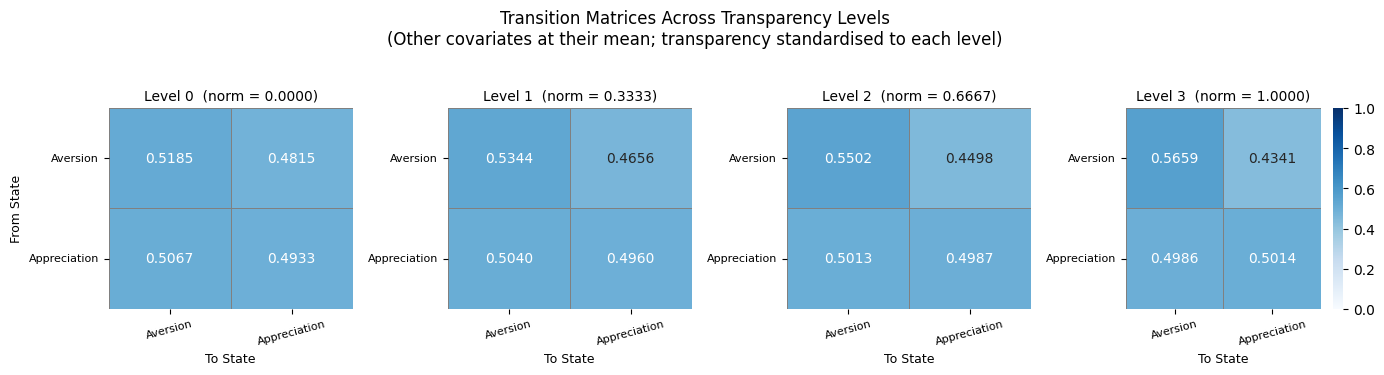


Transition matrices by transparency level (display order):

  Level 0 (norm = 0.0000):
    From Aversion: [0.5185 0.4815]
    From Appreciation: [0.5067 0.4933]

  Level 1 (norm = 0.3333):
    From Aversion: [0.5344 0.4656]
    From Appreciation: [0.504 0.496]

  Level 2 (norm = 0.6667):
    From Aversion: [0.5502 0.4498]
    From Appreciation: [0.5013 0.4987]

  Level 3 (norm = 1.0000):
    From Aversion: [0.5659 0.4341]
    From Appreciation: [0.4986 0.5014]


In [67]:

# ============================================================
# Transition Probabilities Under Alternative Transparency Levels
#
#   For each transparency level t ∈ {0, 1, 2, 3}:
#     t_norm = t / 3.0   (raw normalized value)
#     x[t_idx] = (t_norm - x_sc.mean_[t_idx]) / x_sc.scale_[t_idx]
#               (standardised, as the model was fit on standardised X)
#     Other covariates held at 0 in standardised space (= their mean).
#     logits[i,j] = α[i,j] + Σ_p β[i,j,p] * x[p]
#     Q(t)[i,:] = softmax(logits[i,:])
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from IPython.display import display, HTML

# ── 0. Model parameters ─────────────────────────────────────
_alpha = best_model.alpha           # (J, J)
_beta  = best_model.beta            # (J, J, P)
_J     = int(best_J)
_P     = _beta.shape[2]

# Covariate index for transparency_level_norm (always last = P-1)
_t_idx = _P - 1

# Standardisation parameters for transparency_level_norm
_t_mean  = float(x_sc.mean_[_t_idx])
_t_scale = float(x_sc.scale_[_t_idx])

# State labels in display order
_labels = [label_map[s] for s in state_order_1idx]

# ── 1. Compute Q at each transparency level ──────────────────
transparency_levels   = [0, 1, 2, 3]
transparency_norm     = [t / 3.0 for t in transparency_levels]

trans_matrices = {}                  # keyed by raw level integer

for t_raw, t_norm in zip(transparency_levels, transparency_norm):
    x = np.zeros(_P)
    x[_t_idx] = (t_norm - _t_mean) / _t_scale   # standardised value

    Q_t = np.zeros((_J, _J))
    for i in range(_J):
        logits = _alpha[i] + _beta[i] @ x   # shape (J,)
        Q_t[i] = softmax(logits)

    trans_matrices[t_raw] = Q_t

# ── 2. Heatmap grid ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))

for ax, t_raw in zip(axes, transparency_levels):
    Q_t = trans_matrices[t_raw]

    # Reorder to display order
    Q_disp = Q_t[np.ix_(
        [s - 1 for s in state_order_1idx],
        [s - 1 for s in state_order_1idx]
    )]

    sns.heatmap(
        Q_disp,
        ax=ax,
        annot=True,
        fmt=".4f",
        cmap="Blues",
        vmin=0.0, vmax=1.0,
        xticklabels=_labels,
        yticklabels=_labels,
        cbar=(t_raw == 3),          # only rightmost gets a colorbar
        linewidths=0.5,
        linecolor="grey",
    )
    ax.set_title(
        f"Level {t_raw}  (norm = {t_raw/3:.4f})",
        fontsize=10, pad=6
    )
    ax.set_xlabel("To State", fontsize=9)
    ax.set_ylabel("From State" if t_raw == 0 else "", fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=15)
    ax.tick_params(axis="y", labelsize=8, rotation=0)

fig.suptitle(
    "Transition Matrices Across Transparency Levels\n"
    "(Other covariates at their mean; transparency standardised to each level)",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()

# ── 3. Summary table ─────────────────────────────────────────
rows = []
for t_raw in transparency_levels:
    Q_t = trans_matrices[t_raw]
    for i in range(_J):
        from_label = label_map[state_order_1idx[i]]
        for j in range(_J):
            to_label = label_map[state_order_1idx[j]]
            rows.append({
                "Transparency Level": t_raw,
                "norm (= level/3)": f"{t_raw/3:.4f}",
                "From State": from_label,
                "To State": to_label,
                "Transition Prob.": round(
                    float(Q_t[state_order_1idx[i] - 1, state_order_1idx[j] - 1]), 4
                ),
            })

trans_df = pd.DataFrame(rows)

# ── 4. Pivot for compact view ────────────────────────────────
pivot_trans = trans_df.pivot_table(
    index=["From State", "To State"],
    columns="Transparency Level",
    values="Transition Prob.",
)
pivot_trans.columns = [
    f"L{c}  (norm={c/3:.4f})" for c in pivot_trans.columns
]
pivot_trans = pivot_trans.round(4).reset_index()

html_parts = []
html_parts.append(
    "<h4>Transition Probabilities Under Alternative Transparency Levels</h4>"
    "<p style='font-size:0.85em;color:#555;'>"
    "Transition probabilities Q(t)[i→j] = softmax(α[i] + β[i,j,:]·x) with "
    "x[transparency] = (t/3 − mean) / sd (standardised as in model estimation), "
    "all other covariates held at 0 in standardised space (= their sample mean). "
    "Each column corresponds to one of the four experimental transparency levels.</p>"
)
html_parts.append(
    pivot_trans.to_html(index=False, border=1, classes="table table-sm")
)

# ── 5. Change in transition probability relative to Level 0 ──
rows_delta = []
Q0 = trans_matrices[0]
for t_raw in transparency_levels[1:]:
    Qt = trans_matrices[t_raw]
    for i in range(_J):
        from_label = label_map[state_order_1idx[i]]
        for j in range(_J):
            to_label = label_map[state_order_1idx[j]]
            p0 = float(Q0[state_order_1idx[i] - 1, state_order_1idx[j] - 1])
            pt = float(Qt[state_order_1idx[i] - 1, state_order_1idx[j] - 1])
            rows_delta.append({
                "From → To": f"{from_label} → {to_label}",
                f"ΔP at L{t_raw} vs L0": round(pt - p0, 4),
            })

changes_data = []
pair_labels = list(dict.fromkeys(r["From → To"] for r in rows_delta))
for pair in pair_labels:
    r = {"From → To": pair}
    for t_raw in transparency_levels[1:]:
        key = f"ΔP at L{t_raw} vs L0"
        match = [x[key] for x in rows_delta if x["From → To"] == pair and key in x]
        r[key] = match[0] if match else np.nan
    changes_data.append(r)

changes_df = pd.DataFrame(changes_data)

html_parts.append(
    "<br><b>Change in transition probability relative to Level 0 (ΔP = P(L_k) − P(L_0))</b>"
)
html_parts.append(
    changes_df.to_html(index=False, border=1, classes="table table-sm", na_rep="–")
)
html_parts.append(
    "<p style='font-size:0.80em;color:#888;'>"
    "Positive ΔP means transparency level k makes that transition more likely "
    "than Level 0.</p>"
)

display(HTML("\n".join(html_parts)))

# Quick console summary
print("\nTransition matrices by transparency level (display order):")
for t_raw in transparency_levels:
    Q_t = trans_matrices[t_raw]
    Q_disp = Q_t[np.ix_(
        [s - 1 for s in state_order_1idx],
        [s - 1 for s in state_order_1idx]
    )]
    print(f"\n  Level {t_raw} (norm = {t_raw/3:.4f}):")
    for i, fl in enumerate(_labels):
        print(f"    From {fl}: {np.round(Q_disp[i], 4)}")


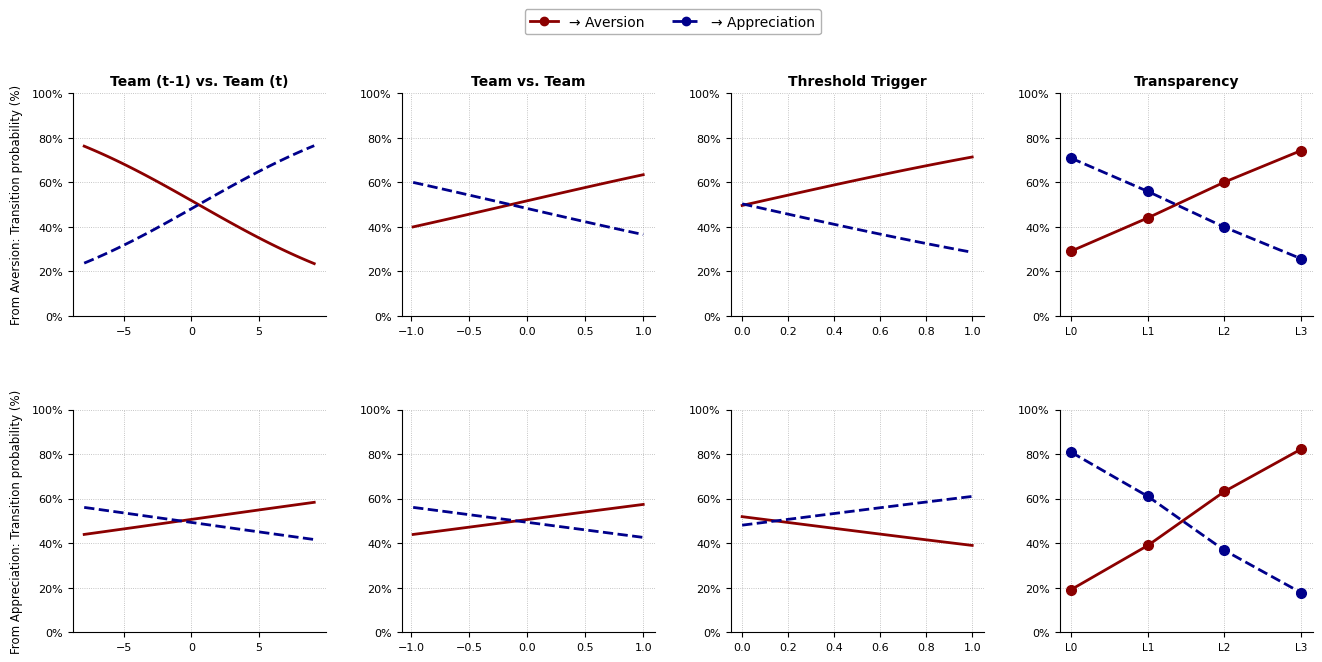

✔ Saved: kpi_sensitivity_analysis_misq.png


In [68]:

# ============================================================
# KPI-Driven Sensitivity Analysis  —  State-Transition Line Plots
#   MISQ-ready version
#
#   For each of the 4 transition covariates:
#     • Vary that covariate over its observed range (raw scale)
#     • Standardise for model input; others fixed at 0 in
#       standardised space (= sample mean on raw scale)
#     • Plot P(St+1 = k | St = j) for each origin state j
#
#   Layout:  2 rows × 4 cols
#     row 0 = origin Aversion
#     row 1 = origin Appreciation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import matplotlib.lines as mlines
from scipy.special import softmax

_alpha  = best_model.alpha
_beta   = best_model.beta
_J      = int(best_J)
_P      = _beta.shape[2]
_labels = [label_map[s] for s in state_order_1idx]   # ['Aversion', 'Appreciation']
_idx    = [s - 1 for s in state_order_1idx]

# ── Covariate metadata (updated labels) ────────────────────
x_cols = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
]
x_nice = [
    "Team (t-1) vs. Team (t)",
    "Team vs. Team",
    "Threshold Trigger",
    "Transparency",
]

_n_grid  = 50
_pal     = ["#8B0000", "#00008B"]   # → Aversion: dark red; → Appreciation: dark blue
_ls_dest = ["-", "--"]

# ── Row labels ──────────────────────────────────────────────
_row_ylabels = [
    f"From {_labels[0]}: Transition probability (%)",
    f"From {_labels[1]}: Transition probability (%)",
]

fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 7),
    sharey=False,
    gridspec_kw={"hspace": 0.42, "wspace": 0.30},
)

for col_idx, (col, nice) in enumerate(zip(x_cols, x_nice)):
    p_idx = col_idx
    mu_p  = float(x_sc.mean_[p_idx])
    sd_p  = float(x_sc.scale_[p_idx])

    col_raw = df[col].dropna().values
    z_lo    = float((col_raw.min() - mu_p) / sd_p)
    z_hi    = float((col_raw.max() - mu_p) / sd_p)

    is_transparency = (col == "transparency_level_norm")

    if is_transparency:
        raw_grid = np.array([0, 1/3, 2/3, 1.0])
        z_grid   = (raw_grid - mu_p) / sd_p
    else:
        z_grid   = np.linspace(z_lo, z_hi, _n_grid)
        raw_grid = z_grid * sd_p + mu_p

    for row_idx, (from_0idx, from_label_r) in enumerate(zip(_idx, _labels)):
        ax = axes[row_idx, col_idx]

        for dest_i, (to_0idx, to_label) in enumerate(zip(_idx, _labels)):
            probs = []
            for z in z_grid:
                xv = np.zeros(_P)
                xv[p_idx] = z
                logits = _alpha[from_0idx] + _beta[from_0idx] @ xv
                q_row  = softmax(logits)
                probs.append(q_row[to_0idx])

            ax.plot(
                np.arange(4) if is_transparency else raw_grid,
                [p * 100 for p in probs],
                color=_pal[dest_i],
                ls=_ls_dest[dest_i],
                lw=2.0,
                marker="o" if is_transparency else None,
                markersize=7 if is_transparency else 0,
            )

        # ── Axes formatting ─────────────────────────────────
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 20))
        ax.grid(True, ls=":", lw=0.6, color="gray", alpha=0.6)
        ax.tick_params(labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

        # Column titles (top row only)
        if row_idx == 0:
            ax.set_title(nice, fontsize=10, pad=6, fontweight="bold")

        # Left y-axis label (leftmost column only)
        if col_idx == 0:
            ax.set_ylabel(_row_ylabels[row_idx], fontsize=8.5, labelpad=6)

        # x-axis
        if is_transparency:
            ax.set_xticks([0, 1, 2, 3])
            ax.set_xticklabels(
                ["L0", "L1", "L2", "L3"],
                fontsize=7.5,
            )

# ── Figure-level legend (placed above panels, centred) ────
legend_handles = [
    mlines.Line2D([], [], color=_pal[0], ls=_ls_dest[0], lw=2.0,
                  marker="o", markersize=6, label=f"→ {_labels[0]}"),
    mlines.Line2D([], [], color=_pal[1], ls=_ls_dest[1], lw=2.0,
                  marker="o", markersize=6, label=f"→ {_labels[1]}"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor="#aaa",
    bbox_to_anchor=(0.5, 1.01),
)

plt.savefig(
    "kpi_sensitivity_analysis_misq.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print("✔ Saved: kpi_sensitivity_analysis_misq.png")


## State distribution over time

In [69]:
# ============================================================
# 4.2a. State distribution over time (2-state version)
#   - Uses your computed label_map + state_order_1idx
#   - Ensures plots show: Aversion â†’ Transitionary â†’ Appreciation
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()

# Add/refresh labels using YOUR label_map
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Order labels: Aversion â†’ Transitionary â†’ Appreciation
label_order = [label_map[s] for s in state_order_1idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------------------------
# 1) Overall distribution (bar chart)
# ----------------------------
freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

# Add percentage labels
total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# ----------------------------
# 2) Proportion over time (stacked area)
# ----------------------------
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()


AssertionError: posteriors not found. Run the posterior assignment cell first.

## Average of AI authority share and escalation rate

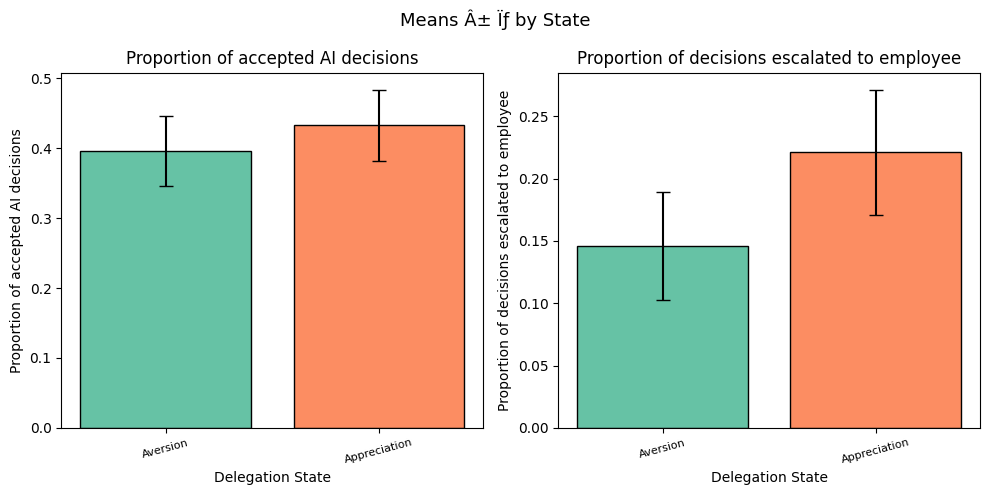

In [ ]:
# ============================================================
# 4.2b. Emission means by state (original scale) â€” 3-state version
#   - Only the 2 independent emission dimensions
#     (AI Decision Authority Share, Escalation Share)
#   - override_rate omitted (= 1 âˆ’ authority by construction)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# Only independent dimensions
independent_dims = {
    0: ("ai_decision_authority_share", "Proportion of accepted AI decisions"),
    1: ("share_authority_esc", "Proportion of decisions escalated to employee"),
}

n_panels = len(independent_dims)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
axes = np.atleast_1d(axes)

state_order_1idx = list(state_order_1idx)
state_order_0idx = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

palette = sns.color_palette("Set2", len(label_order))

for ax_idx, (d, (col, nice_name)) in enumerate(independent_dims.items()):
    ax = axes[ax_idx]

    vals = [mu_orig[s, d] for s in state_order_0idx]
    errs = [sigma_orig[s, d] for s in state_order_0idx]

    ax.bar(
        label_order,
        vals,
        yerr=errs,
        capsize=5,
        color=palette,
        edgecolor="k"
    )
    ax.set_xlabel("Delegation State")
    ax.set_ylabel(nice_name)
    ax.set_title(nice_name)
    ax.tick_params(axis="x", labelsize=8, rotation=15)

plt.suptitle("Means Â± Ïƒ by State", fontsize=13)
plt.tight_layout()
plt.show()


## Appreciation - Aversion Transition dynamics

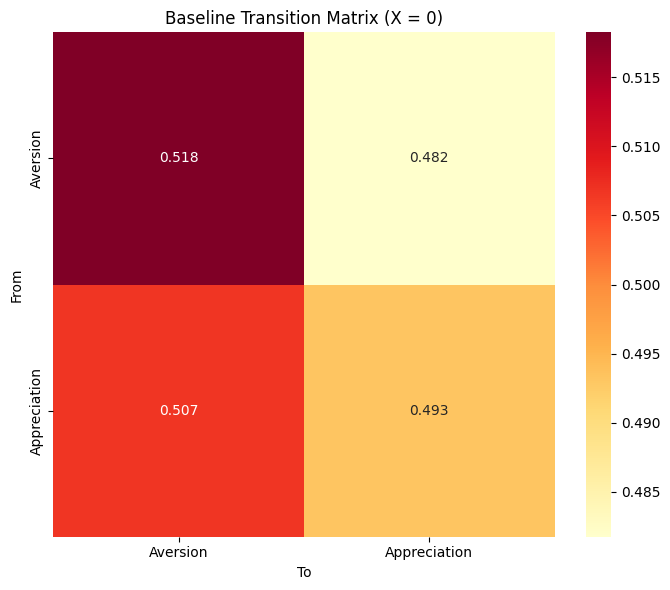


Transition probabilities (rows sum to 1):
  From Aversion: [0.518 0.482]
  From Appreciation: [0.507 0.493]


In [ ]:
# ============================================================
# 4.2c. Transition matrix heatmap (baseline, at X=0) â€” 3-state version
#   - Uses your computed label_map + state_order_1idx
#   - Displays in order: Aversion â†’ Transitionary â†’ Appreciation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# ---- Baseline transition matrix at X=0 ----
Q_base = np.zeros((best_J, best_J))
for j in range(best_J):
    logits = best_model.alpha[j]
    Q_base[j] = softmax(logits)

# ---- Display order: Aversion â†’ Transitionary â†’ Appreciation ----
state_display_order = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

Q_base_ordered = Q_base[np.ix_(state_display_order, state_display_order)]

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    Q_base_ordered,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Baseline Transition Matrix (X = 0)")
plt.tight_layout()
plt.show()

# ---- Print formatted rows ----
print("\nTransition probabilities (rows sum to 1):")
for i, from_label in enumerate(label_order):
    from_state = state_display_order[i]
    probs = " ".join(f"{Q_base[from_state, state_display_order[j]]:.3f}" for j in range(best_J))
    print(f"  From {from_label}: [{probs}]")


## KPI driven transition dynamic

Detected transition covariates in model: P = 6
Transition covariate labels used: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'threshold_benchmark', 'transparency_level_norm', 'transparency_x_operational', 'transparency_x_temporal']
âš ï¸ x_scaler.scale_ not available or dimension mismatch â†’ skipping unscale.

â•â•â•  Transition Covariate Coefficients (Î²)  â•â•â•


â”€â”€ Î² coefficients (scaled X): within_unit_temporal_benchmark â”€â”€


To,Aversion,Appreciation
From,,
Aversion,-0.1852,0.1354
Appreciation,0.0135,-0.0659



â”€â”€ Î² coefficients (scaled X): horizontal_peer_benchmark â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1192,-0.1591
Appreciation,0.1080,-0.0499


Detected transition covariates in model: P = 6
Transition covariate labels used: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'threshold_benchmark', 'transparency_level_norm', 'transparency_x_operational', 'transparency_x_temporal']
âš ï¸ x_scaler.scale_ not available or dimension mismatch â†’ skipping unscale.

â•â•â•  Transition Covariate Coefficients (Î²)  â•â•â•


â”€â”€ Î² coefficients (scaled X): within_unit_temporal_benchmark â”€â”€


...


â”€â”€ Î² coefficients (scaled X): horizontal_peer_benchmark â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1192,-0.1591
Appreciation,0.1080,-0.0499



â”€â”€ Î² coefficients (scaled X): threshold_benchmark â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1241,-0.1475
Appreciation,-0.0742,0.0789



â•â•â•  Simulated Transition Matrices Under Shocks (Â±1 SD, scaled X)  â•â•â•



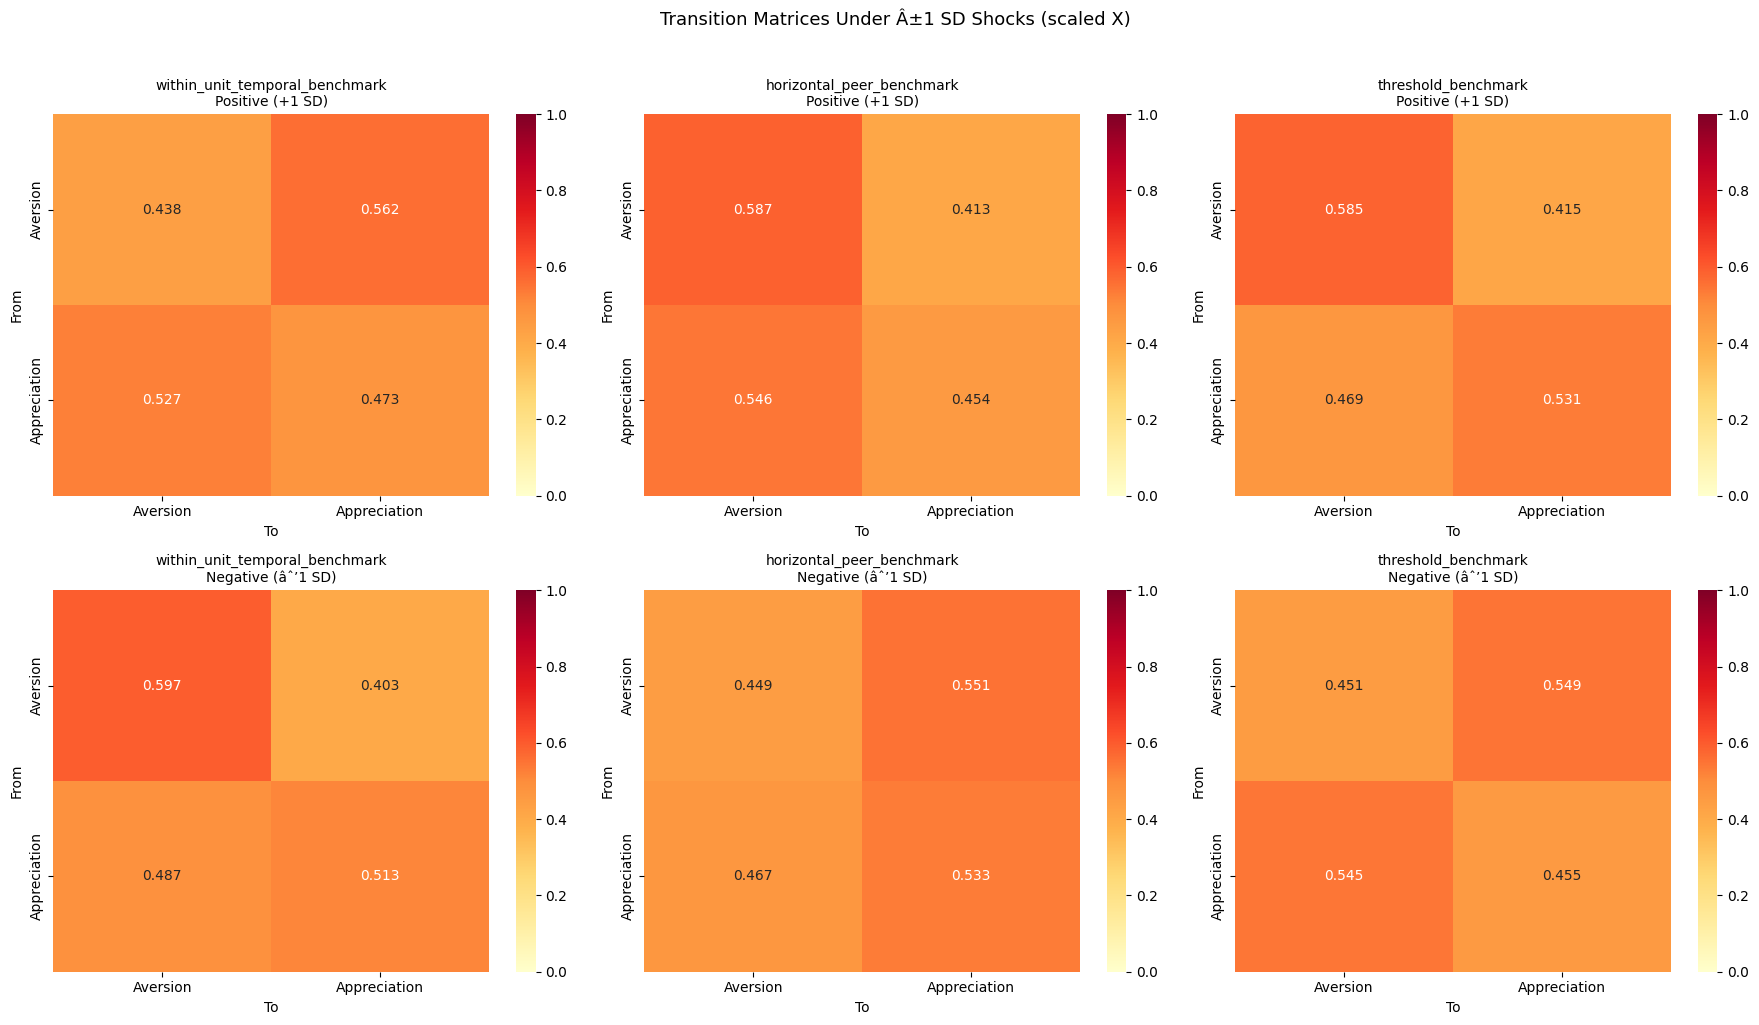


â•â•â•  Asymmetry: Avg Î”P(â†’Aversion) vs Avg Î”P(â†’Appreciation)  â•â•â•



,Covariate,Shock,Avg Î”P(â†’Aversion),Avg Î”P(â†’Appreciation)
0,within_unit_temporal_benchmark,Positive (+1SD),-0.0300,0.0300
1,within_unit_temporal_benchmark,Negative (âˆ’1SD),0.0295,-0.0295
2,horizontal_peer_benchmark,Positive (+1SD),0.0540,-0.0540
3,horizontal_peer_benchmark,Negative (âˆ’1SD),-0.0544,0.0544
4,threshold_benchmark,Positive (+1SD),0.0144,-0.0144
5,threshold_benchmark,Negative (âˆ’1SD),-0.0148,0.0148



âœ“ Result 5.1.2: Transition coefficients and shock simulations for 2 states.


In [ ]:
# ============================================================
# KPI-Driven State Transitions (J-aware: works for J=2 or J=3)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

assert "label_map" in globals(), "label_map not found. Run STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run STATE LABELING cell first."

# Display order: Aversion â†’ [Transitionary â†’] Appreciation
state_display_order_0 = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

aversion_idx0      = state_display_order_0[0]
appreciation_idx0  = state_display_order_0[-1]   # works for J=2 and J=3
transitionary_idx0 = state_display_order_0[1] if len(state_display_order_0) > 2 else None

# ------------------------------------------------------------
# 0) Infer P from the fitted model
# ------------------------------------------------------------
beta = best_model.beta
assert beta.ndim == 3, f"Expected beta to be 3D (J,J,P). Got {beta.shape}."
P_model = beta.shape[2]
print(f"Detected transition covariates in model: P = {P_model}")

transition_cols_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]

if P_model <= len(transition_cols_full):
    transition_cols = transition_cols_full[:P_model]
else:
    transition_cols = transition_cols_full + [f"x_cov_{i}" for i in range(len(transition_cols_full), P_model)]

print("Transition covariate labels used:", transition_cols)

# Unscale if scaler matches P
if hasattr(data, "x_scaler") and hasattr(data.x_scaler, "scale_") and len(data.x_scaler.scale_) == P_model:
    beta_orig = beta / data.x_scaler.scale_[None, None, :]
    have_unscale = True
else:
    beta_orig = beta.copy()
    have_unscale = False
    print("âš ï¸ x_scaler.scale_ not available or dimension mismatch â†’ skipping unscale.")

# ------------------------------------------------------------
# a) Beta coefficient table
# ------------------------------------------------------------
print("\nâ•â•â•  Transition Covariate Coefficients (Î²)  â•â•â•\n")
beta_rows = []
for p_idx, cov in enumerate(transition_cols):
    for from_pos, from_label in enumerate(label_order):
        i0 = state_display_order_0[from_pos]
        for to_pos, to_label in enumerate(label_order):
            j0 = state_display_order_0[to_pos]
            row = {
                "Covariate": cov,
                "From": from_label,
                "To": to_label,
                "Î² (scaled)": round(float(beta[i0, j0, p_idx]), 4),
            }
            if have_unscale:
                row["Î² (orig units)"] = round(float(beta_orig[i0, j0, p_idx]), 4)
            beta_rows.append(row)

beta_df = pd.DataFrame(beta_rows)

# Print pivots for up to 3 covariates
for cov in transition_cols[:3]:
    sub = beta_df[beta_df["Covariate"] == cov].pivot(index="From", columns="To", values="Î² (scaled)")
    print(f"\nâ”€â”€ Î² coefficients (scaled X): {cov} â”€â”€")
    display(sub.reindex(index=label_order, columns=label_order).round(4))

# ------------------------------------------------------------
# b) Simulated transition matrices at Â±1 SD of KPI (scaled space)
# ------------------------------------------------------------
print("\nâ•â•â•  Simulated Transition Matrices Under Shocks (Â±1 SD, scaled X)  â•â•â•\n")

kpi_covariates = [(transition_cols[i], i) for i in range(min(3, P_model))]
n_cov = len(kpi_covariates)

fig, axes = plt.subplots(2, n_cov, figsize=(6*n_cov, 10), squeeze=False)

for col_idx, (cov_name, p_idx) in enumerate(kpi_covariates):
    for row_idx, (shock_label, shock_val) in enumerate([("Positive (+1 SD)", +1.0),
                                                         ("Negative (âˆ’1 SD)", -1.0)]):
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        Q_shock = np.zeros((best_J, best_J))
        for i0 in range(best_J):
            logits = best_model.alpha[i0] + best_model.beta[i0] @ x_vec
            Q_shock[i0] = softmax(logits)

        Q_shock_ordered = Q_shock[np.ix_(state_display_order_0, state_display_order_0)]

        ax = axes[row_idx, col_idx]
        sns.heatmap(
            Q_shock_ordered,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax,
            vmin=0,
            vmax=1.0
        )
        ax.set_title(f"{cov_name}\n{shock_label}", fontsize=10)
        ax.set_xlabel("To")
        ax.set_ylabel("From")

plt.suptitle("Transition Matrices Under Â±1 SD Shocks (scaled X)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# c) Asymmetry quantification
# ------------------------------------------------------------
print("\nâ•â•â•  Asymmetry: Avg Î”P(â†’Aversion) vs Avg Î”P(â†’Appreciation)  â•â•â•\n")

asym_rows = []
for cov_name, p_idx in kpi_covariates:
    for shock_label, shock_val in [("Positive (+1SD)", +1.0), ("Negative (âˆ’1SD)", -1.0)]:
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        d_to_av, d_to_trans, d_to_app = [], [], []
        for i0 in range(best_J):
            p_base  = softmax(best_model.alpha[i0])
            p_shock = softmax(best_model.alpha[i0] + best_model.beta[i0] @ x_vec)

            d_to_av.append(p_shock[aversion_idx0] - p_base[aversion_idx0])
            if transitionary_idx0 is not None:
                d_to_trans.append(p_shock[transitionary_idx0] - p_base[transitionary_idx0])
            d_to_app.append(p_shock[appreciation_idx0] - p_base[appreciation_idx0])

        row = {
            "Covariate": cov_name,
            "Shock": shock_label,
            "Avg Î”P(â†’Aversion)": round(float(np.mean(d_to_av)), 4),
            "Avg Î”P(â†’Appreciation)": round(float(np.mean(d_to_app)), 4),
        }
        if transitionary_idx0 is not None:
            row["Avg Î”P(â†’Transitionary)"] = round(float(np.mean(d_to_trans)), 4)
        asym_rows.append(row)

asym_df = pd.DataFrame(asym_rows)
display(asym_df)

print(f"\nâœ“ Result 5.1.2: Transition coefficients and shock simulations for {best_J} states.")


## Transparency effects on transition dynamics

â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



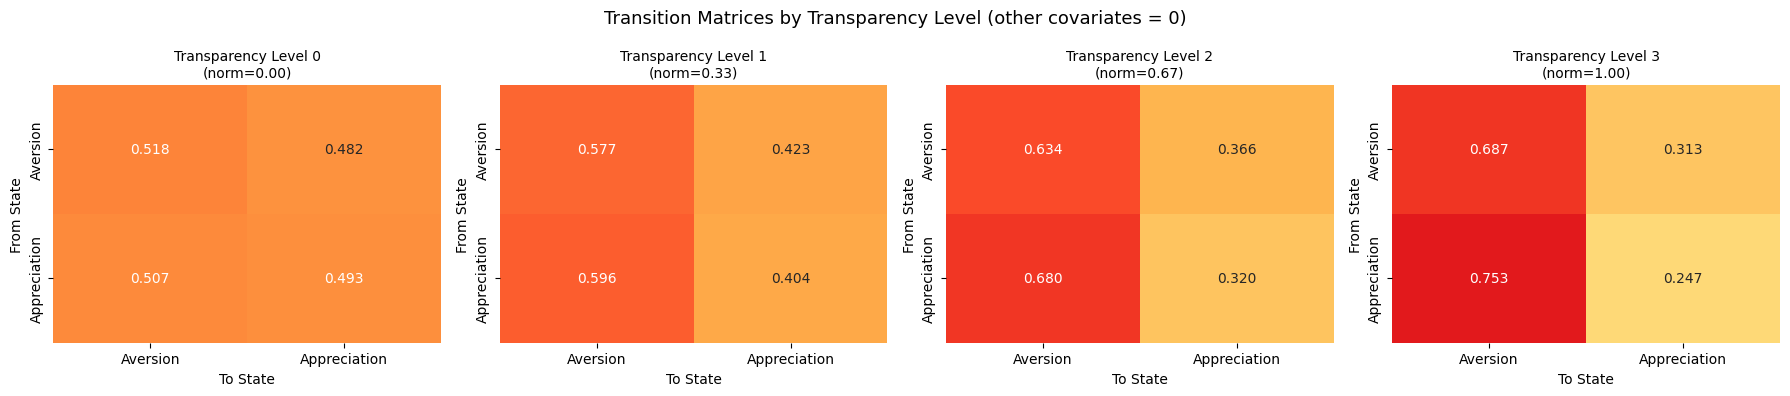


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



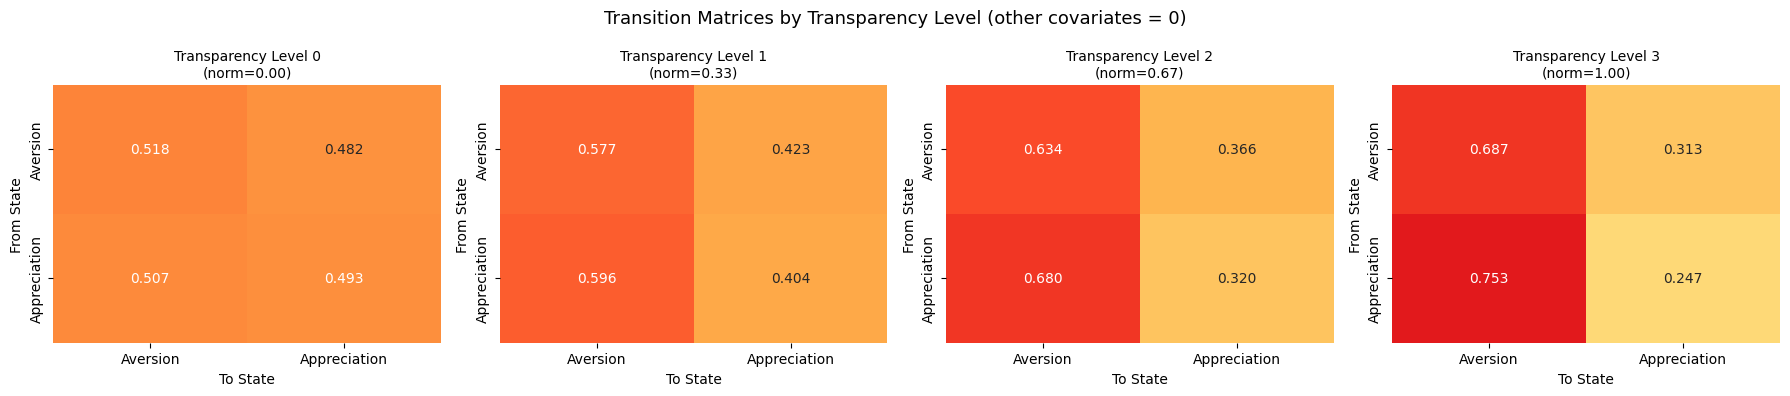


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â”€â”€ Î” P  (Level 3 âˆ’ Level 0) â”€â”€


â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



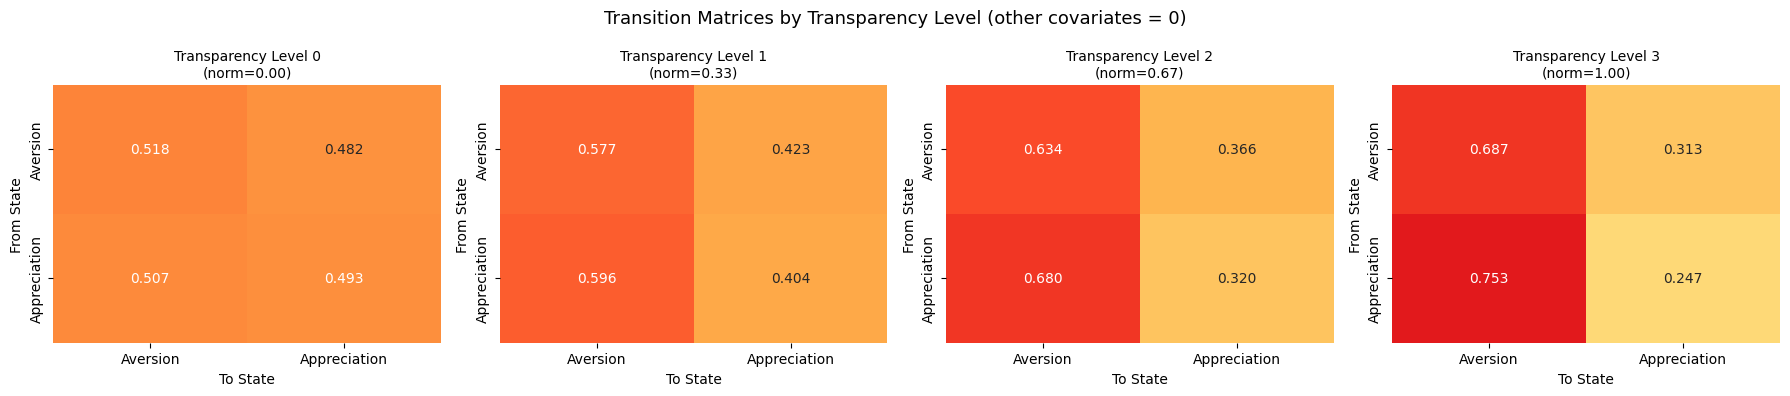


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â”€â”€ Î” P  (Level 3 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1692,-0.1692
Appreciation,0.2467,-0.2467


â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



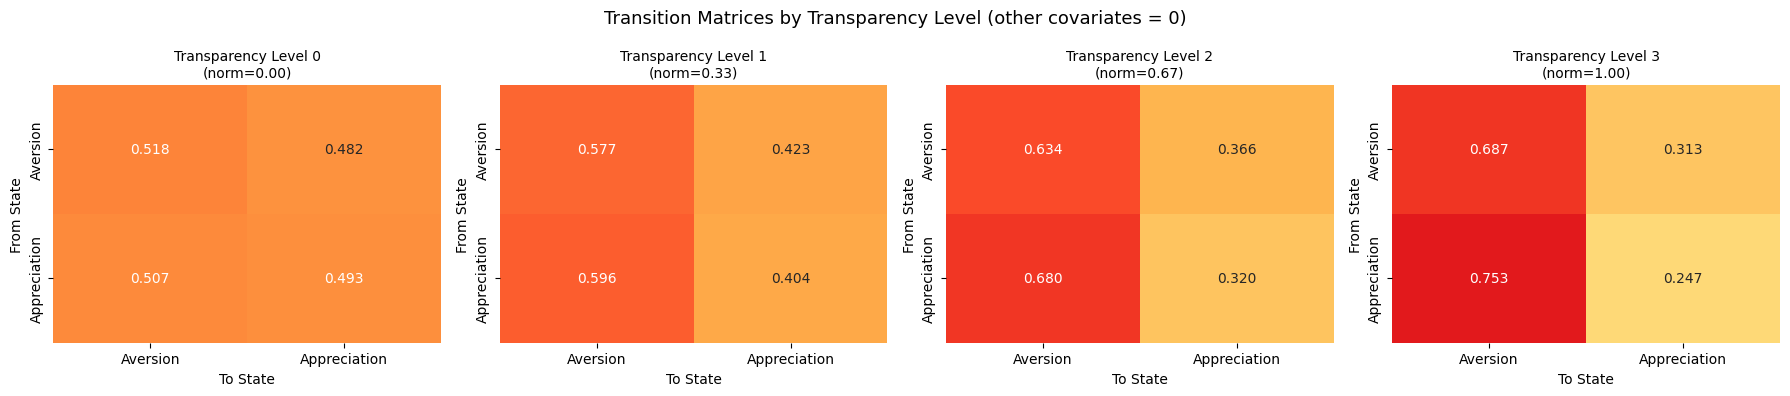


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â”€â”€ Î” P  (Level 3 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1692,-0.1692
Appreciation,0.2467,-0.2467


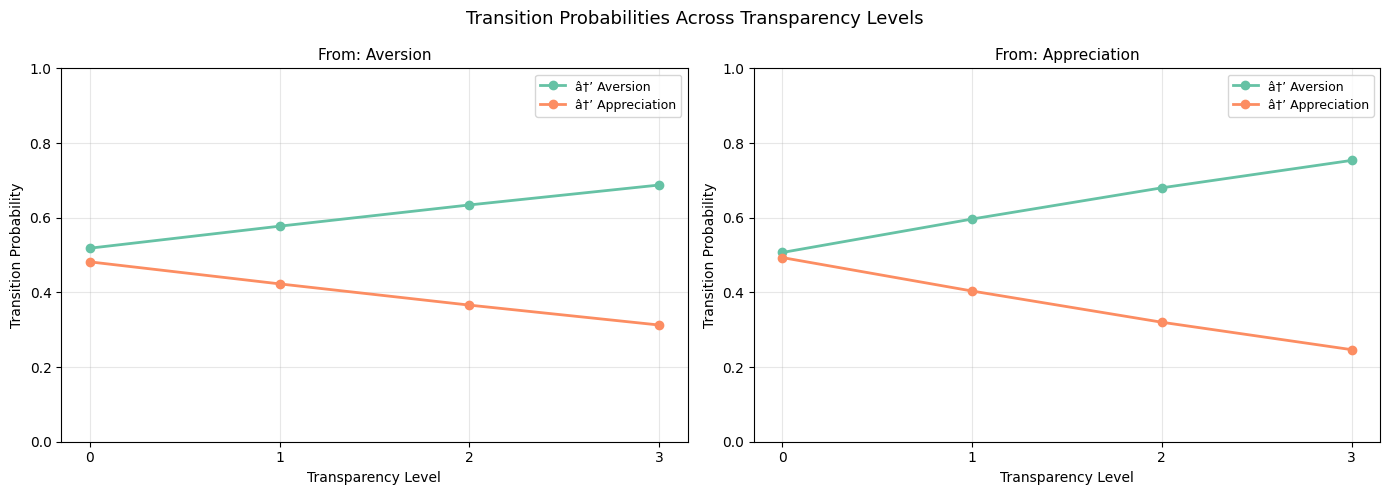

â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



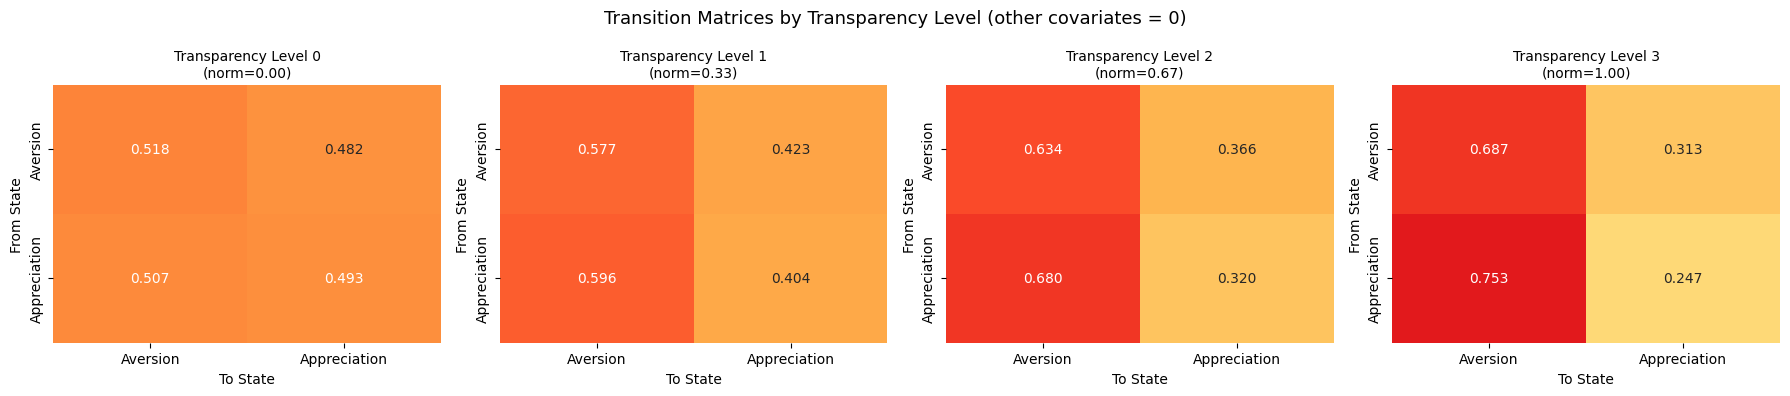


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â”€â”€ Î” P  (Level 3 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1692,-0.1692
Appreciation,0.2467,-0.2467


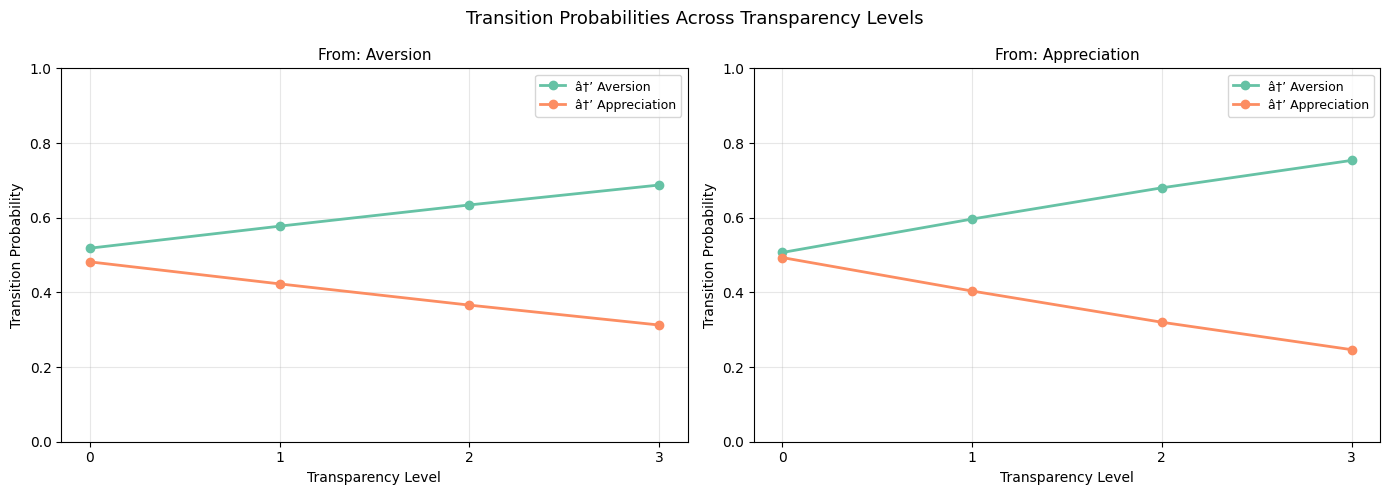

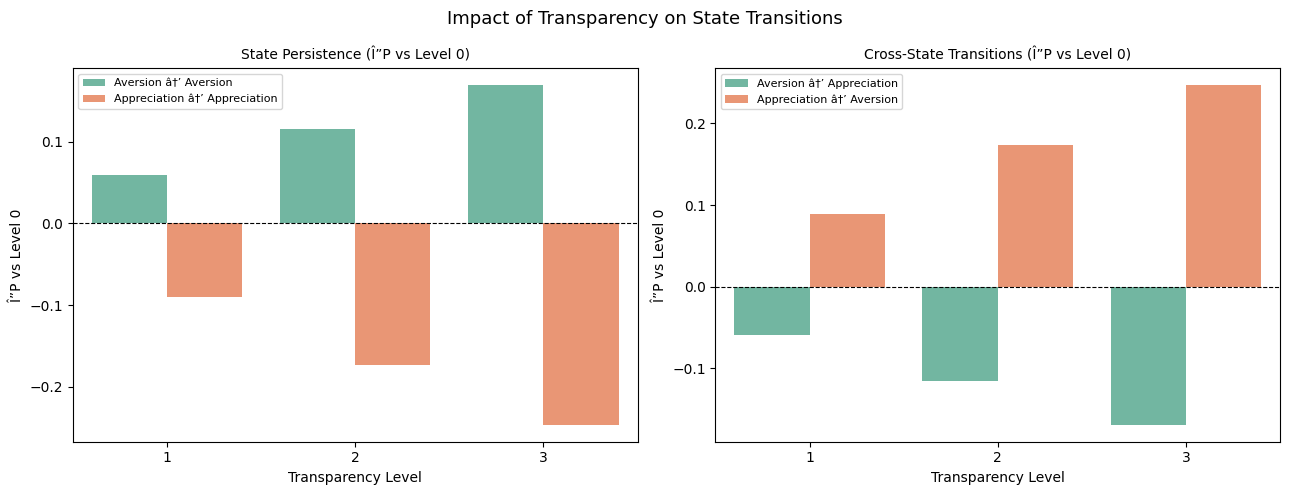


â•â•â•  Î² Coefficients for Transparency Covariates  â•â•â•

â”€â”€ transparency_level_norm (index 3) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.3716**,-0.3436*
Appreciation,0.5394***,-0.5505***



â”€â”€ transparency_x_operational (index 4) â”€â”€


â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



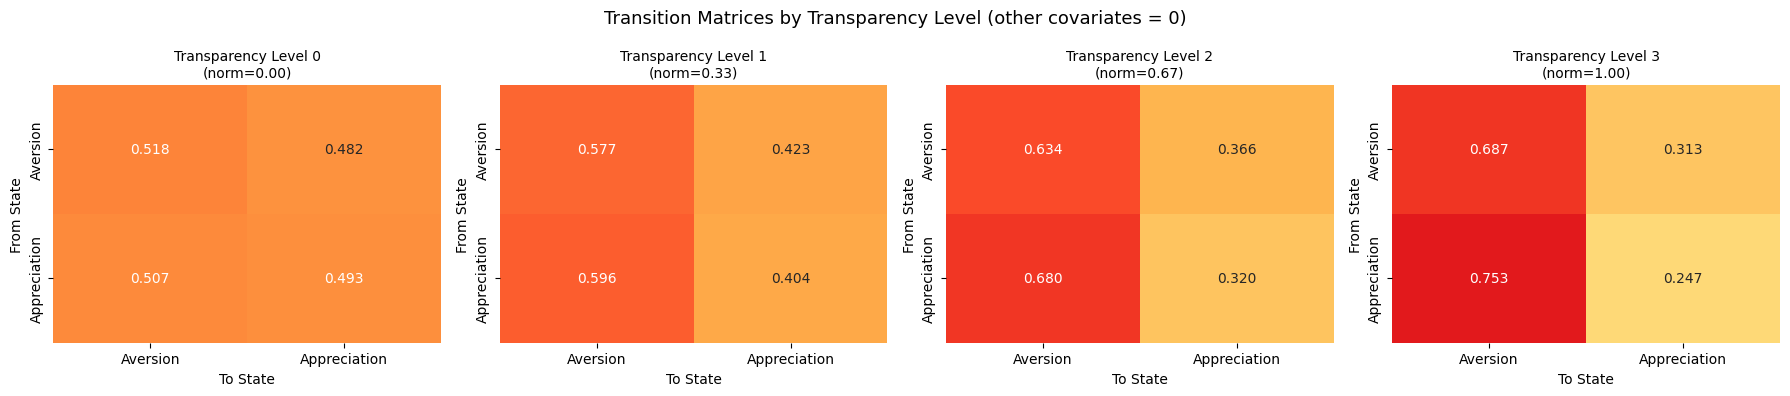


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â”€â”€ Î” P  (Level 3 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1692,-0.1692
Appreciation,0.2467,-0.2467


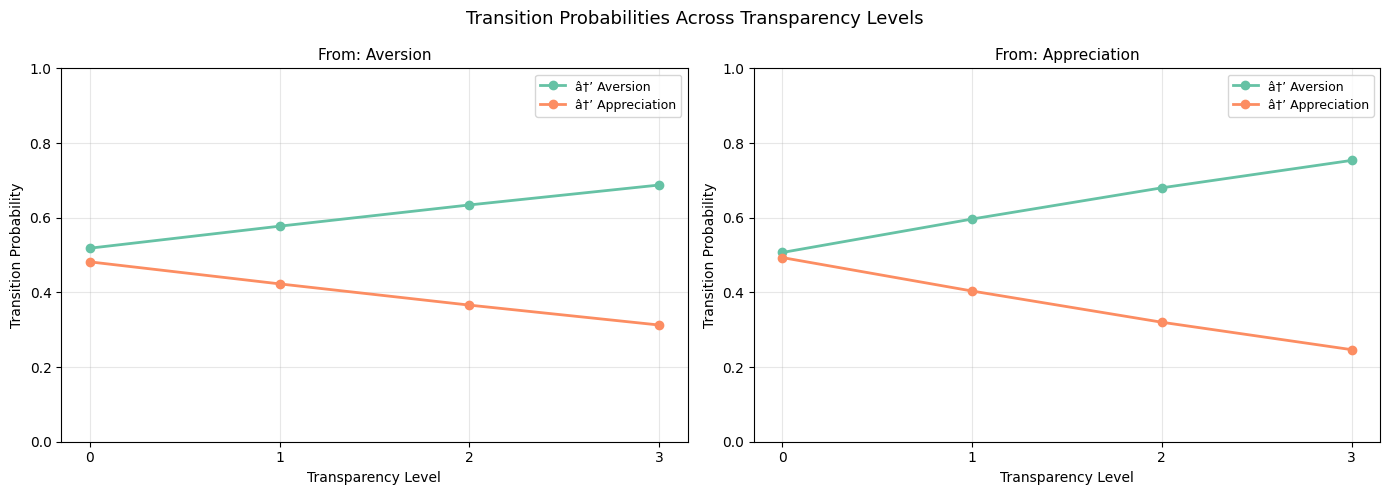

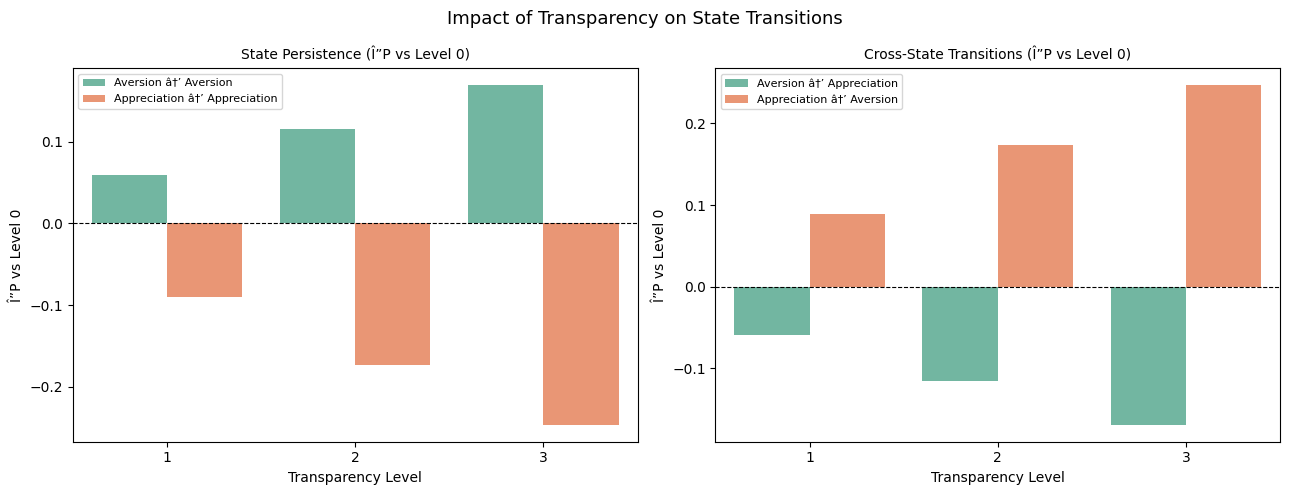


â•â•â•  Î² Coefficients for Transparency Covariates  â•â•â•

â”€â”€ transparency_level_norm (index 3) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.3716**,-0.3436*
Appreciation,0.5394***,-0.5505***



â”€â”€ transparency_x_operational (index 4) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,-0.0597,0.0757
Appreciation,0.0448,-0.0349



â”€â”€ transparency_x_temporal (index 5) â”€â”€


â•â•â•  Transparency Effects on State Transitions  â•â•â•

Model P = 6 transition covariates
  transparency_level_norm index : 3
  transparency_x_operational    : 4
  transparency_x_temporal       : 5



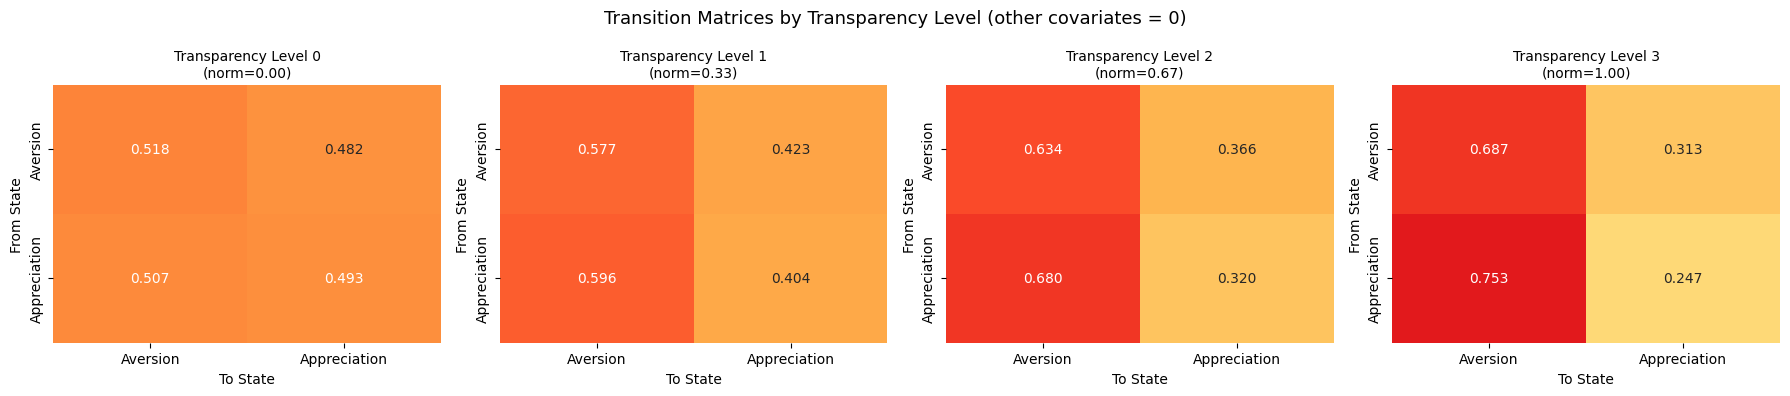


â•â•â•  Transition Probability Changes vs Level 0  â•â•â•

â”€â”€ Î” P  (Level 1 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.0590,-0.0590
Appreciation,0.0896,-0.0896


â”€â”€ Î” P  (Level 2 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1158,-0.1158
Appreciation,0.1732,-0.1732


â”€â”€ Î” P  (Level 3 âˆ’ Level 0) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1692,-0.1692
Appreciation,0.2467,-0.2467


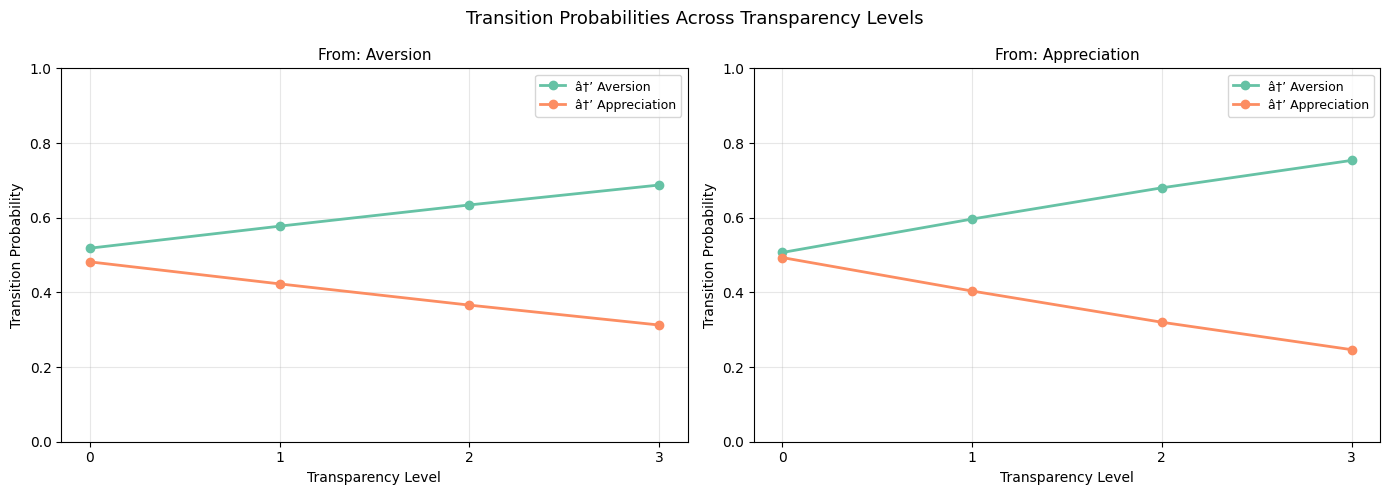

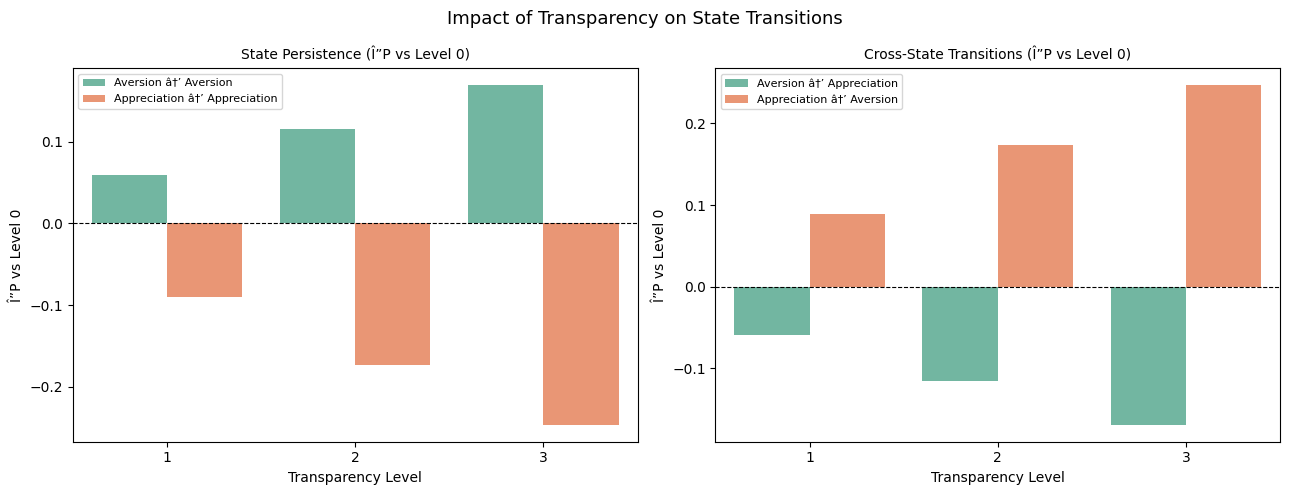


â•â•â•  Î² Coefficients for Transparency Covariates  â•â•â•

â”€â”€ transparency_level_norm (index 3) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.3716**,-0.3436*
Appreciation,0.5394***,-0.5505***



â”€â”€ transparency_x_operational (index 4) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,-0.0597,0.0757
Appreciation,0.0448,-0.0349



â”€â”€ transparency_x_temporal (index 5) â”€â”€


To,Aversion,Appreciation
From,,
Aversion,0.1389,-0.1421
Appreciation,-0.0176,0.0302



â•â•â•  Summary: Average |Î”P| by Transparency Level  â•â•â•



,Mean |Î”P|,Max |Î”P|
Transparency Level,,
1,0.0743,0.0896
2,0.1445,0.1732
3,0.2079,0.2467



âœ“ Transparency analysis complete. Levels 0â€“3; transparency_level_norm at index 3.


In [ ]:

# ============================================================
# Transparency Effects on Transition Dynamics (4-level analysis)
#   - Computes transition matrices at each transparency level (0â€“3)
#   - Uses fitted beta coefficients for transparency_level_norm
#     (other covariates held at zero = mean of scaled data)
#   - Compares changes relative to Level 0 baseline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from IPython.display import display

print("â•â•â•  Transparency Effects on State Transitions  â•â•â•\n")

# â”€â”€ Fitted parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
J_t    = int(best_J)
alpha  = best_model.alpha   # (J, J)
beta_t = best_model.beta    # (J, J, P)
P_t    = beta_t.shape[2]

trans_cov_names = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
][:P_t]

def _idx(name):
    return trans_cov_names.index(name) if name in trans_cov_names else None

trans_main_idx = _idx("transparency_level_norm")
trans_op_idx   = _idx("transparency_x_operational")
trans_temp_idx = _idx("transparency_x_temporal")

print(f"Model P = {P_t} transition covariates")
print(f"  transparency_level_norm index : {trans_main_idx}")
print(f"  transparency_x_operational    : {trans_op_idx}")
print(f"  transparency_x_temporal       : {trans_temp_idx}\n")

# â”€â”€ State display order â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
state_labels  = [label_map[s] for s in state_order_1idx]
state_order_0 = [s - 1 for s in state_order_1idx]

# â”€â”€ 1. Transition matrices at each transparency level â”€â”€â”€â”€â”€â”€â”€
transparency_levels = [0, 1, 2, 3]
transparency_norm   = [t / 3.0 for t in transparency_levels]

trans_matrices = {}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, t_raw, t_norm in zip(axes, transparency_levels, transparency_norm):
    x_vec = np.zeros(P_t)
    if trans_main_idx is not None:
        x_vec[trans_main_idx] = t_norm

    Q = np.zeros((J_t, J_t))
    for j_from in range(J_t):
        logits = alpha[j_from] + beta_t[j_from] @ x_vec
        Q[j_from] = softmax(logits)

    Q_ord = Q[np.ix_(state_order_0, state_order_0)]
    trans_matrices[t_raw] = Q_ord

    sns.heatmap(Q_ord, annot=True, fmt=".3f", cmap="YlOrRd",
                xticklabels=state_labels, yticklabels=state_labels,
                ax=ax, vmin=0, vmax=1.0, cbar=False)
    ax.set_title(f"Transparency Level {t_raw}\n(norm={t_norm:.2f})", fontsize=10)
    ax.set_xlabel("To State")
    ax.set_ylabel("From State")

plt.suptitle("Transition Matrices by Transparency Level (other covariates = 0)", fontsize=13)
plt.tight_layout()
plt.show()

# â”€â”€ 2. Changes vs Level-0 baseline â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\nâ•â•â•  Transition Probability Changes vs Level 0  â•â•â•\n")

baseline = trans_matrices[0]
changes_data = []

for t_raw in [1, 2, 3]:
    diff = trans_matrices[t_raw] - baseline
    diff_df = pd.DataFrame(diff, index=state_labels, columns=state_labels)
    diff_df.index.name = "From"; diff_df.columns.name = "To"
    print(f"â”€â”€ Î” P  (Level {t_raw} âˆ’ Level 0) â”€â”€")
    display(diff_df.round(4))

    for i, fs in enumerate(state_labels):
        for j, ts in enumerate(state_labels):
            changes_data.append({
                "Transparency Level": t_raw,
                "From": fs, "To": ts,
                "Transition": f"{fs} â†’ {ts}",
                "Î”P": diff[i, j],
            })

changes_df = pd.DataFrame(changes_data)

# â”€â”€ 3. Transition probability vs transparency (line plots) â”€â”€
fig2, axes2 = plt.subplots(1, J_t, figsize=(7 * J_t, 5))
axes2 = np.atleast_1d(axes2)
pal = sns.color_palette("Set2", J_t)
levels_all = transparency_levels

for ax, from_label in zip(axes2, state_labels):
    for j_col, to_label in enumerate(state_labels):
        probs = [float(trans_matrices[t][state_labels.index(from_label), j_col])
                 for t in levels_all]
        ax.plot(levels_all, probs, marker="o", label=f"â†’ {to_label}",
                color=pal[j_col], linewidth=2)
    ax.set_title(f"From: {from_label}", fontsize=11)
    ax.set_xlabel("Transparency Level")
    ax.set_ylabel("Transition Probability")
    ax.set_xticks(levels_all)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Transition Probabilities Across Transparency Levels", fontsize=13)
plt.tight_layout()
plt.show()

# â”€â”€ 4. Bar chart of Î”P by transition type â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
pers_list  = [f"{s} â†’ {s}" for s in state_labels]
cross_list = [f"{s} â†’ {t}" for s in state_labels for t in state_labels if s != t]

for ax, subset_list, title in zip(
        axes3,
        [pers_list, cross_list],
        ["State Persistence (Î”P vs Level 0)", "Cross-State Transitions (Î”P vs Level 0)"]):
    sub = changes_df[changes_df["Transition"].isin(subset_list)]
    sns.barplot(data=sub, x="Transparency Level", y="Î”P",
                hue="Transition", ax=ax, palette="Set2")
    ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Î”P vs Level 0")
    ax.legend(fontsize=8)

plt.suptitle("Impact of Transparency on State Transitions", fontsize=13)
plt.tight_layout()
plt.show()

# â”€â”€ 5. Beta coefficients for transparency terms â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\nâ•â•â•  Î² Coefficients for Transparency Covariates  â•â•â•\n")

for cov_name, p_i in [
        ("transparency_level_norm",    trans_main_idx),
        ("transparency_x_operational", trans_op_idx),
        ("transparency_x_temporal",    trans_temp_idx)]:
    if p_i is None:
        continue
    print(f"â”€â”€ {cov_name} (index {p_i}) â”€â”€")
    rows_ = []
    for ri, fs in enumerate(state_labels):
        for ci, ts in enumerate(state_labels):
            rr = state_order_0[ri]; cc = state_order_0[ci]
            b_val = float(beta_t[rr, cc, p_i])
            stars = ""
            if "p_beta" in dir() and p_beta is not None:
                pv = float(p_beta[rr, cc, p_i])
                if pv < 0.01: stars = "***"
                elif pv < 0.05: stars = "**"
                elif pv < 0.10: stars = "*"
            rows_.append({"From": fs, "To": ts,
                          "Î²": round(b_val, 4), "sig": stars})
    b_piv = (pd.DataFrame(rows_)
               .assign(cell=lambda x: x["Î²"].astype(str) + x["sig"])
               .pivot(index="From", columns="To", values="cell"))
    b_piv = b_piv[state_labels].reindex(state_labels)
    display(b_piv)
    print()

# â”€â”€ 6. Summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("â•â•â•  Summary: Average |Î”P| by Transparency Level  â•â•â•\n")
summary = (changes_df
    .assign(abs_delta=changes_df["Î”P"].abs())
    .groupby("Transparency Level")["abs_delta"]
    .agg(["mean", "max"])
    .rename(columns={"mean": "Mean |Î”P|", "max": "Max |Î”P|"}))
display(summary.round(4))

print(f"\nâœ“ Transparency analysis complete. Levels 0â€“3; transparency_level_norm at index {trans_main_idx}.")


## Triadic Delegation Flows: Authority and Execution

In [ ]:

# ============================================================
# Triadic Delegation Flows â€” Task-Level Evidence (J=2, D=2)
# ============================================================
# Emission D=0 : ai_decision_authority_share  (AI-accepted / total tasks)
# Emission D=1 : share_authority_esc          (Team-escalated / total tasks)
# HMM States  : Appreciation | Aversion
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from IPython.display import display

print(f"Loading from: {xlsx_path.resolve()}\n")
print("â•â•â•  Loading Task-Level Episode Tables  â•â•â•\n")

# â”€â”€ 1. Load episode sheets â”€â”€
dec_ep  = pd.read_excel(xlsx_path, sheet_name="decision_episode")
exec_ep = pd.read_excel(xlsx_path, sheet_name="execution_episode")
print(f"decision_episode : {dec_ep.shape[0]:,} tasks  ({dec_ep.shape[1]} cols)")
print(f"execution_episode: {exec_ep.shape[0]:,} tasks  ({exec_ep.shape[1]} cols)")

# â”€â”€ 2. Directly flag the two HMM emission categories â”€â”€
# D=0 : ai_decision_authority_share  â†’ manager_action == "accept"  AND escalation_flag == 0
# D=1 : share_authority_esc          â†’ escalation_flag == 1
dec_ep["is_ai_accepted"]  = ((dec_ep["manager_action"] == "accept") &
                              (dec_ep["escalation_flag"] == 0)).astype(int)
dec_ep["is_escalated"]    = (dec_ep["escalation_flag"] == 1).astype(int)

# â”€â”€ 3. Merge execution mode â”€â”€
emp_override_col = "employee_override_during_execution"
exec_mode = exec_ep[["episode_id", "execution_mode"]].copy()
exec_mode[emp_override_col] = (
    exec_ep[emp_override_col] if emp_override_col in exec_ep.columns else 0
)
exec_mode_agg = (
    exec_mode.groupby("episode_id")
    .agg(execution_mode=(  "execution_mode",  lambda x: x.mode().iloc[0]),
         any_emp_override=(emp_override_col,   "max"))
    .reset_index()
)
tasks = dec_ep.merge(exec_mode_agg, on="episode_id", how="left")
tasks["any_emp_override"] = tasks["any_emp_override"].fillna(0)
print(f"\nMerged task table: {tasks.shape[0]:,} rows")

# â”€â”€ 4. Aggregate per manager-period: D=0 & D=1 shares â”€â”€
print("\nâ•â•â•  Per Manager-Period D=2 Emission Shares  â•â•â•\n")

task_agg = (
    tasks.groupby(["manager_id", "period_id"])
    .agg(
        n_tasks_total   =("episode_id",    "count"),
        n_ai_accepted   =("is_ai_accepted","sum"),
        n_escalated     =("is_escalated",  "sum"),
    )
    .reset_index()
)
task_agg["share_authority_ai"]  = task_agg["n_ai_accepted"] / task_agg["n_tasks_total"]  # D=0
task_agg["share_authority_esc"] = task_agg["n_escalated"]   / task_agg["n_tasks_total"]  # D=1

# Execution mode counts
exec_counts = (
    tasks.groupby(["manager_id", "period_id", "execution_mode"])
    .size().unstack(fill_value=0).reset_index()
)
exec_counts.columns.name = None
for c in ["ai", "human", "joint"]:
    if c not in exec_counts.columns:
        exec_counts[c] = 0
exec_counts.rename(columns={"ai": "n_exec_ai",
                             "human": "n_exec_employee",
                             "joint": "n_exec_joint"}, inplace=True)

# Employee override rate per manager-period
emp_override_agg = (
    tasks.groupby(["manager_id", "period_id"])
    .agg(emp_override_rate=("any_emp_override", "mean"))
    .reset_index()
)

task_agg = (task_agg
            .merge(exec_counts, on=["manager_id", "period_id"], how="left")
            .merge(emp_override_agg, on=["manager_id", "period_id"], how="left")
            .fillna(0))

exec_total = (task_agg["n_exec_ai"] + task_agg["n_exec_employee"] + task_agg["n_exec_joint"]
              ).replace(0, np.nan)
task_agg["share_exec_ai"]       = task_agg["n_exec_ai"]       / exec_total
task_agg["share_exec_employee"] = task_agg["n_exec_employee"] / exec_total
task_agg["share_exec_joint"]    = task_agg["n_exec_joint"]    / exec_total
task_agg[["share_exec_ai", "share_exec_employee", "share_exec_joint"]] = \
    task_agg[["share_exec_ai", "share_exec_employee", "share_exec_joint"]].fillna(0)

# â”€â”€ 5. Link to HMM states â”€â”€
task_state = task_agg.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner"
)
task_state["state_label"] = task_state["most_likely_state"].map(label_map)
print(f"Task-State merged: {task_state.shape[0]:,} manager-period observations")

state_labels_ordered = [label_map[s] for s in state_order_1idx]
print(f"State order: {state_labels_ordered}\n")

# â”€â”€ 6. Emission validation: observed means vs HMM Âµ â”€â”€
print("â•â•â•  Observed D=2 Emission Means by HMM State  â•â•â•")
print("    (compare to Âµ[j,0] and Âµ[j,1] from the fitted HMM)\n")

em_by_state = (
    task_state.groupby("state_label")[["share_authority_ai", "share_authority_esc"]]
    .mean().reindex(state_labels_ordered)
)
em_by_state.columns = ["D=0  ai_decision_authority_share", "D=1  share_authority_esc"]
display(em_by_state.round(4))

print("\n  HMM model Âµ:")
if have_unscale and y_sc is not None:
    mu_unsc = y_sc.inverse_transform(best_model.mu[state_order_0idx])
    mu_display = pd.DataFrame(mu_unsc, index=state_labels_ordered,
                               columns=["D=0  Âµ (HMM, unscaled)", "D=1  Âµ (HMM, unscaled)"])
else:
    mu_display = pd.DataFrame(best_model.mu[state_order_0idx], index=state_labels_ordered,
                               columns=["D=0  Âµ (HMM, scaled)", "D=1  Âµ (HMM, scaled)"])
display(mu_display.round(4))

# â”€â”€ 7. D=2 emission table â”€â”€
print("\nâ•â•â•  D=2 Emission Shares by HMM State  â•â•â•\n")
em_display = em_by_state.copy()
em_display.index.name = "HMM State"
display(em_display.round(4))

# â”€â”€ 8. Execution flow table â”€â”€
print("\nâ•â•â•  Execution Flow Distribution by HMM State  â•â•â•\n")
exec_by_state = (
    task_state.groupby("state_label")
    [["share_exec_ai", "share_exec_employee", "share_exec_joint"]]
    .mean().reindex(state_labels_ordered)
)
exec_by_state.columns = ["AI-Executed", "Employee-Executed", "Joint Execution"]
display(exec_by_state.round(4))

# â”€â”€ 9. Visualisation: D=2 grouped bar + execution stacked bar â”€â”€
colors_d2  = ["#4C72B0", "#55A868"]   # D=0 blue, D=1 green
colors_exc = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar for 2 emissions
x       = np.arange(len(state_labels_ordered))
width   = 0.35
bars_d0 = axes[0].bar(x - width/2, em_by_state["D=0  ai_decision_authority_share"],
                       width, label="D=0  AI Authority Share", color=colors_d2[0], edgecolor="k")
bars_d1 = axes[0].bar(x + width/2, em_by_state["D=1  share_authority_esc"],
                       width, label="D=1  Escalation Share",   color=colors_d2[1], edgecolor="k")
axes[0].set_xticks(x)
axes[0].set_xticklabels(state_labels_ordered, fontsize=10)
axes[0].set_ylabel("Mean Share of Tasks")
axes[0].set_title("HMM Emissions (D=0 & D=1) by State  (J=2)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max(em_by_state.values.max() * 1.25, 0.4))
for bar in list(bars_d0) + list(bars_d1):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=8)

# Right: execution stacked bar
exec_by_state.plot(kind="bar", stacked=True, ax=axes[1],
                   color=colors_exc, edgecolor="k", width=0.55)
axes[1].set_title("Execution Flow by HMM State  (J=2)", fontsize=12)
axes[1].set_ylabel("Mean Share of Tasks")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[1].legend(title="Execution Mode", fontsize=8, loc="upper left")
axes[1].set_ylim(0, 1.05)

plt.suptitle("Triadic Delegation Flows by HMM State  (J=2, D=2)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# â”€â”€ 10. Mann-Whitney tests for D=0 and D=1 â”€â”€
print("â•â•â•  Statistical Tests: D=2 Emissions by State (Mann-Whitney)  â•â•â•\n")
s0_label, s1_label = state_labels_ordered[0], state_labels_ordered[1]

for d_idx, (col, label) in enumerate([
    ("share_authority_ai",  "ai_decision_authority_share"),
    ("share_authority_esc", "share_authority_esc"),
]):
    g0 = task_state.loc[task_state["state_label"] == s0_label, col].values
    g1 = task_state.loc[task_state["state_label"] == s1_label, col].values
    _, p_ = ttest_ind(g0, g1, equal_var=False)
    sig_   = "significantly different" if p_ < 0.05 else "not significantly different"
    print(f"D={d_idx}  {label}:")
    print(f"  Welch's t-test:  p = {p_:.6f},  {sig_}")
    print(f"  {s0_label}: n={len(g0)},  mean={g0.mean():.4f}")
    print(f"  {s1_label}: n={len(g1)},  mean={g1.mean():.4f}\n")

# Chi-sq: AI authority majority Ã— state
print("â•â•â•  Chi-Squared: AI Authority Majority Ã— HMM State  â•â•â•\n")
ct_auth = pd.crosstab(
    task_state["state_label"],
    (task_state["share_authority_ai"] > 0.5).map({True: "AI-Majority", False: "Non-AI-Majority"})
)
print(ct_auth)
chi2_val, p_chi, dof, _ = chi2_contingency(ct_auth)
print(f"\nÏ‡Â² = {chi2_val:.2f}, p = {p_chi:.6f}, dof = {dof}")

# â”€â”€ 11. Employee override by state â”€â”€
print("\nâ•â•â•  Employee Override During Execution by State  â•â•â•\n")
task_state2 = task_state.copy()
override_by_state = (
    task_state2.groupby("state_label")["emp_override_rate"]
    .agg(["mean", "std", "count"])
    .reindex(state_labels_ordered)
)
override_by_state.columns = ["Mean Override Rate", "Std", "Count"]
display(override_by_state.round(4))

fig2, ax2 = plt.subplots(figsize=(7, 4))
override_by_state["Mean Override Rate"].plot(
    kind="bar", ax=ax2,
    color=sns.color_palette("Set2", 2), edgecolor="k", width=0.5
)
ax2.set_ylabel("Employee Override Rate\n(during AI-assisted execution)")
ax2.set_title("Employee Override of AI During Execution â€” by HMM State  (J=2)")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "â•" * 60)
print("âœ“ Triadic delegation flows â€” J=2, D=2 HMM.")
print(f"  D=0 : ai_decision_authority_share")
print(f"  D=1 : share_authority_esc")
print(f"  States : {s0_label}  |  {s1_label}")
print("â•" * 60)


Loading from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\new run\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx

â•â•â•  Loading Task-Level Episode Tables  â•â•â•



Loading from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\new run\Triadic_Delegation_Dataset_SYNTH_ANALYSIS_v2.xlsx

â•â•â•  Loading Task-Level Episode Tables  â•â•â•



KeyboardInterrupt: 

## State-Dependent Time Trend of Delegation Decisions

In [ ]:

# ============================================================
# State-Dependent Time Trend of Delegation Decisions
# Two separate figures â€” one per emission (D=0 and D=1)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import linregress

# â”€â”€ Emission definitions â”€â”€
emissions = [
    ("share_authority_ai",  "Tasks Delegated to AI (%)",       "state_time_trend_D0_ai_authority.png"),
    ("share_authority_esc", "Tasks Escalated to Team (%)",      "state_time_trend_D1_escalation.png"),
]

# â”€â”€ State style map â”€â”€
state_styles = {
    state_labels_ordered[0]: dict(color="#8B0000", ls="--",  lw=1.8, label=f"State {state_labels_ordered[0]}"),
    state_labels_ordered[1]: dict(color="#00008B", ls="-.",  lw=1.8, label=f"State {state_labels_ordered[1]}"),
}

for col, ylabel, fname in emissions:

    trend_df = (
        task_state.groupby(["period_id", "state_label"])[col]
        .mean()
        .reset_index()
    )
    trend_df[col] *= 100
    trend_df = trend_df.sort_values("period_id")
    periods = np.sort(trend_df["period_id"].unique())

    fig, ax = plt.subplots(figsize=(8, 5))

    for state, sty in state_styles.items():
        sub = trend_df[trend_df["state_label"] == state].sort_values("period_id")
        if sub.shape[0] < 2:
            continue
        t = sub["period_id"].values.astype(float)
        y = sub[col].values
        slope, intercept, *_ = linregress(t, y)
        t_fit = np.array([periods.min(), periods.max()])
        y_fit = intercept + slope * t_fit
        ax.plot(t_fit, y_fit,
                color=sty["color"], ls=sty["ls"], lw=sty["lw"],
                label=sty["label"])

    ax.set_xlabel("Time Period (Week)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set_xlim(periods.min() - 1, periods.max() + 1)
    ax.set_ylim(
        max(0,   trend_df[col].min() - 10),
        min(100, trend_df[col].max() + 10),
    )
    ax.grid(True, ls=":", lw=0.7, color="gray", alpha=0.7)
    ax.legend(fontsize=10, frameon=True)
    ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"âœ“ Saved: {fname}")


NameError: name 'task_state' is not defined

State,Aversion,Appreciation
N obs (manager-period),1539,1461
N obs (%),51.30%,48.70%
Avg tasks / period,45.6,46.0
AI authority share (μ),39.64%,43.29%
AI authority share (σ),5.00%,5.09%
Escalation share (μ),14.62%,22.14%
Escalation share (σ),4.31%,5.01%
Manager-retained (implied),45.73%,34.57%
Exec: AI-only (%),33.18%,32.33%
Exec: Employee-only (%),38.87%,39.64%


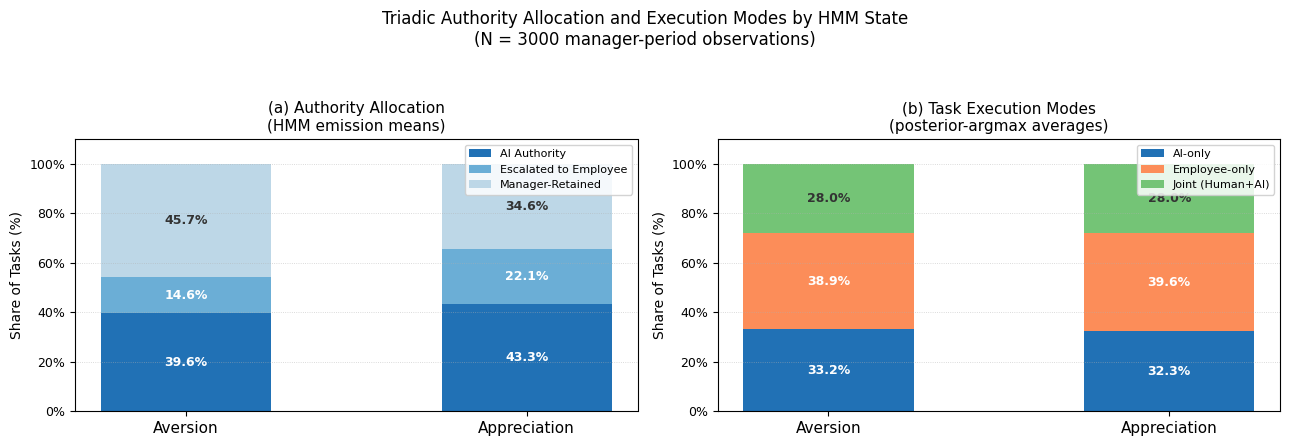

✔ Saved: triadic_authority_execution_by_state.png

══════════════════════════════════════════════════════
 TRIADIC AUTHORITY ALLOCATION & EXECUTION MODES — SUMMARY
══════════════════════════════════════════════════════

Total observations: 3000 manager-period units
  Aversion: N=1539 (51.30%)
  Appreciation: N=1461 (48.70%)

─── Authority Allocation (observed means + MWU test) ───
  Metric                       Aversion  Appreciation    p-value  sig
  --------------------------- ---------  ------------  ---------  ---
  AI authority share             37.04%        32.13%     0.0000  ***
  Escalation share               13.77%        23.33%     0.0000  ***
  Manager-retained (obs.)        49.18%        44.54%     0.0000  ***

─── Execution Modes (observed means + MWU test) ───
  Metric                       Aversion  Appreciation    p-value  sig
  --------------------------- ---------  ------------  ---------  ---
  AI-only execution              33.18%        32.33%     0.1535  n.s.
  

In [ ]:

# ============================================================
# Triadic Authority Allocation and Execution Modes by HMM State
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
from scipy.special import softmax
from scipy.stats import ttest_ind

# ── 0. Core quantities ────────────────────────────────────
_labels   = [label_map[s] for s in state_order_1idx]
_idx0     = [s - 1 for s in state_order_1idx]
_J        = int(best_J)

ai_mu   = [float(mu_orig[_idx0[i], 0]) for i in range(_J)]
esc_mu  = [float(mu_orig[_idx0[i], 1]) for i in range(_J)]
mgr_mu  = [1.0 - ai_mu[i] - esc_mu[i]  for i in range(_J)]
ai_sd   = [float(sigma_orig[_idx0[i], 0]) for i in range(_J)]
esc_sd  = [float(sigma_orig[_idx0[i], 1]) for i in range(_J)]

grp     = task_state.groupby('state_label')
exec_ai  = {lbl: float(grp.get_group(lbl)['share_exec_ai'].mean())       for lbl in _labels}
exec_emp = {lbl: float(grp.get_group(lbl)['share_exec_employee'].mean()) for lbl in _labels}
exec_jnt = {lbl: float(grp.get_group(lbl)['share_exec_joint'].mean())    for lbl in _labels}
emp_ovr  = {lbl: float(grp.get_group(lbl)['emp_override_rate'].mean())   for lbl in _labels}
n_tasks  = {lbl: float(grp.get_group(lbl)['n_tasks_total'].mean())       for lbl in _labels}
n_obs    = task_state['state_label'].value_counts().to_dict()

# ── significance helpers ──────────────────────────────────
def _stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "** "
    if p < 0.10:  return "*  "
    return "n.s."

# Add mgr_retained_obs BEFORE slicing
task_state["mgr_retained_obs"] = (
    1 - task_state["share_authority_ai"] - task_state["share_authority_esc"]
)

_av  = task_state[task_state["state_label"] == _labels[0]]
_app = task_state[task_state["state_label"] == _labels[1]]

def _mwu(col):
    a = _av[col].dropna().values
    b = _app[col].dropna().values
    _, p = ttest_ind(a, b, equal_var=False)
    return p

# ── 1. HTML summary table ──────────────────────────────────
rows_html = []
for i, lbl in enumerate(_labels):
    rows_html.append({
        "State": lbl,
        "N obs (manager-period)": n_obs.get(lbl, 0),
        "N obs (%)": f"{100 * n_obs.get(lbl,0) / sum(n_obs.values()):.2f}%",
        "Avg tasks / period": f"{n_tasks[lbl]:.1f}",
        "AI authority share (μ)": f"{ai_mu[i]:.2%}",
        "AI authority share (σ)": f"{ai_sd[i]:.2%}",
        "Escalation share (μ)": f"{esc_mu[i]:.2%}",
        "Escalation share (σ)": f"{esc_sd[i]:.2%}",
        "Manager-retained (implied)": f"{mgr_mu[i]:.2%}",
        "Exec: AI-only (%)": f"{exec_ai[lbl]:.2%}",
        "Exec: Employee-only (%)": f"{exec_emp[lbl]:.2%}",
        "Exec: Joint (%)": f"{exec_jnt[lbl]:.2%}",
        "Employee override rate": f"{emp_ovr[lbl]:.2%}",
    })

summary_df = pd.DataFrame(rows_html).set_index("State")
html_out = [
    "<h4>Table: Triadic Authority Allocation and Execution Modes by HMM State</h4>",
    "<p style='font-size:0.85em;color:#555;'>"
    "Authority allocation shows HMM emission means (μ) and standard deviations (σ) "
    "on the original scale. Manager-retained share is implied as 1 − AI − Escalation. "
    "Execution mode shares are posterior-argmax averages.</p>",
    summary_df.T.to_html(border=1, classes="table table-sm"),
]
display(HTML("\n".join(html_out)))

# ── 2. Stacked bar plots ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x      = np.arange(_J)
width  = 0.5
cols_a = ["#2171b5", "#6baed6", "#bdd7e7"]
cols_e = ["#2171b5", "#fc8d59", "#74c476"]

ax = axes[0]
ai_vals  = [ai_mu[i]  for i in range(_J)]
esc_vals = [esc_mu[i] for i in range(_J)]
mgr_vals = [mgr_mu[i] for i in range(_J)]
ax.bar(x, [v*100 for v in ai_vals],  width, label="AI Authority",         color=cols_a[0])
ax.bar(x, [v*100 for v in esc_vals], width, bottom=[v*100 for v in ai_vals], label="Escalated to Employee", color=cols_a[1])
ax.bar(x, [v*100 for v in mgr_vals], width, bottom=[(ai_mu[i]+esc_mu[i])*100 for i in range(_J)], label="Manager-Retained", color=cols_a[2])
for i in range(_J):
    ax.text(i, ai_vals[i]/2*100, f"{ai_vals[i]:.1%}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(i, (ai_vals[i]+esc_vals[i]/2)*100, f"{esc_vals[i]:.1%}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(i, (ai_vals[i]+esc_vals[i]+mgr_vals[i]/2)*100, f"{mgr_vals[i]:.1%}", ha="center", va="center", fontsize=9, color="#333", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(_labels, fontsize=11)
ax.set_ylabel("Share of Tasks (%)"); ax.set_ylim(0, 110)
ax.set_title("(a) Authority Allocation\n(HMM emission means)", fontsize=11)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax.set_yticks(range(0, 110, 20)); ax.set_yticklabels([f"{v}%" for v in range(0,110,20)], fontsize=9)
ax.grid(True, axis="y", ls=":", lw=0.6, alpha=0.6)

ax = axes[1]
exec_ai_vals  = [exec_ai[lbl]  for lbl in _labels]
exec_emp_vals = [exec_emp[lbl] for lbl in _labels]
exec_jnt_vals = [exec_jnt[lbl] for lbl in _labels]
ax.bar(x, [v*100 for v in exec_ai_vals],  width, label="AI-only", color=cols_e[0])
ax.bar(x, [v*100 for v in exec_emp_vals], width, bottom=[v*100 for v in exec_ai_vals], label="Employee-only", color=cols_e[1])
ax.bar(x, [v*100 for v in exec_jnt_vals], width, bottom=[(exec_ai_vals[i]+exec_emp_vals[i])*100 for i in range(_J)], label="Joint (Human+AI)", color=cols_e[2])
for i in range(_J):
    for val, bot, c in [(exec_ai_vals[i], 0, "white"), (exec_emp_vals[i], exec_ai_vals[i], "white"), (exec_jnt_vals[i], exec_ai_vals[i]+exec_emp_vals[i], "#333")]:
        ax.text(i, (bot+val/2)*100, f"{val:.1%}", ha="center", va="center", fontsize=9, color=c, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(_labels, fontsize=11)
ax.set_ylabel("Share of Tasks (%)"); ax.set_ylim(0, 110)
ax.set_title("(b) Task Execution Modes\n(posterior-argmax averages)", fontsize=11)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax.set_yticks(range(0, 110, 20)); ax.set_yticklabels([f"{v}%" for v in range(0,110,20)], fontsize=9)
ax.grid(True, axis="y", ls=":", lw=0.6, alpha=0.6)

fig.suptitle("Triadic Authority Allocation and Execution Modes by HMM State\n"
             f"(N = {sum(n_obs.values())} manager-period observations)", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig("triadic_authority_execution_by_state.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: triadic_authority_execution_by_state.png")

# ── 3. Console summary with significance tests ─────────────
print("\n══════════════════════════════════════════════════════")
print(" TRIADIC AUTHORITY ALLOCATION & EXECUTION MODES — SUMMARY")
print("══════════════════════════════════════════════════════")
print(f"\nTotal observations: {sum(n_obs.values())} manager-period units")
for lbl in _labels:
    pct = 100 * n_obs.get(lbl, 0) / sum(n_obs.values())
    print(f"  {lbl}: N={n_obs.get(lbl,0)} ({pct:.2f}%)")

print("\n─── Authority Allocation (observed means + MWU test) ───")
print(f"  {'Metric':<27} {'Aversion':>9}  {'Appreciation':>12}  {'p-value':>9}  sig")
print(f"  {'-'*27} {'-'*9}  {'-'*12}  {'-'*9}  ---")
for label_row, col in [
    ("AI authority share",      "share_authority_ai"),
    ("Escalation share",        "share_authority_esc"),
    ("Manager-retained (obs.)", "mgr_retained_obs"),
]:
    av_v  = _av[col].mean()
    app_v = _app[col].mean()
    p     = _mwu(col)
    print(f"  {label_row:<27} {av_v:>9.2%}  {app_v:>12.2%}  {p:>9.4f}  {_stars(p)}")

print("\n─── Execution Modes (observed means + MWU test) ───")
print(f"  {'Metric':<27} {'Aversion':>9}  {'Appreciation':>12}  {'p-value':>9}  sig")
print(f"  {'-'*27} {'-'*9}  {'-'*12}  {'-'*9}  ---")
for label_row, col in [
    ("AI-only execution",   "share_exec_ai"),
    ("Employee-only exec.", "share_exec_employee"),
    ("Joint execution",     "share_exec_joint"),
    ("Employee override",   "emp_override_rate"),
]:
    av_v  = _av[col].mean()
    app_v = _app[col].mean()
    p     = _mwu(col)
    print(f"  {label_row:<27} {av_v:>9.2%}  {app_v:>12.2%}  {p:>9.4f}  {_stars(p)}")

print("\n  Note: * p < 0.1; ** p < 0.05; *** p < 0.01 (two-tailed t-test)")


In [ ]:

# ── Helper: integer hundredths-of-percent arithmetic ─────────────────────────
# Using integer arithmetic ensures residual rows display values that sum to
# exactly 100.00% — floating-point rounding of (1 - a - b) can otherwise
# produce 99.99% artefacts.
def _h(x): return int(round(x * 10000))
def _pct(h): return "{}.{:02d}%".format(h // 100, h % 100)

# ── Authority Allocation (observed means + t-test) ────────────────────────────
print("\n─── Authority Allocation (observed means + t-test) ───")
print(f"  {'Metric':<27} {'Aversion':>9}  {'Appreciation':>12}  {'p-value':>9}  sig")
print(f"  {'-'*27} {'-'*9}  {'-'*12}  {'-'*9}  ---")
_av_ai_h   = _h(_av["share_authority_ai"].mean())
_app_ai_h  = _h(_app["share_authority_ai"].mean())
_av_esc_h  = _h(_av["share_authority_esc"].mean())
_app_esc_h = _h(_app["share_authority_esc"].mean())
_av_mgr_h  = 10000 - _av_ai_h - _av_esc_h
_app_mgr_h = 10000 - _app_ai_h - _app_esc_h
for label_row, col, av_s, app_s in [
    ("AI authority share",      "share_authority_ai",  _pct(_av_ai_h),  _pct(_app_ai_h)),
    ("Escalation share",        "share_authority_esc", _pct(_av_esc_h), _pct(_app_esc_h)),
    ("Manager-retained (obs.)", "mgr_retained_obs",    _pct(_av_mgr_h), _pct(_app_mgr_h)),
]:
    p = _mwu(col)
    print(f"  {label_row:<27} {av_s:>9}  {app_s:>12}  {p:>9.4f}  {_stars(p)}")

# ── Execution Modes (observed means + t-test) ─────────────────────────────────
print("\n─── Execution Modes (observed means + t-test) ───")
print(f"  {'Metric':<27} {'Aversion':>9}  {'Appreciation':>12}  {'p-value':>9}  sig")
print(f"  {'-'*27} {'-'*9}  {'-'*12}  {'-'*9}  ---")
_av_eai_h   = _h(_av["share_exec_ai"].mean())
_app_eai_h  = _h(_app["share_exec_ai"].mean())
_av_eemp_h  = _h(_av["share_exec_employee"].mean())
_app_eemp_h = _h(_app["share_exec_employee"].mean())
_av_ejnt_h  = 10000 - _av_eai_h - _av_eemp_h
_app_ejnt_h = 10000 - _app_eai_h - _app_eemp_h
for label_row, col, av_s, app_s in [
    ("AI-only execution",   "share_exec_ai",       _pct(_av_eai_h),  _pct(_app_eai_h)),
    ("Employee-only exec.", "share_exec_employee", _pct(_av_eemp_h), _pct(_app_eemp_h)),
    ("Joint execution",     "share_exec_joint",    _pct(_av_ejnt_h), _pct(_app_ejnt_h)),
    ("Employee override",   "emp_override_rate",
     f"{_av['emp_override_rate'].mean():.2%}", f"{_app['emp_override_rate'].mean():.2%}"),
]:
    p = _mwu(col)
    print(f"  {label_row:<27} {av_s:>9}  {app_s:>12}  {p:>9.4f}  {_stars(p)}")

print("\n  Note: * p < 0.1; ** p < 0.05; *** p < 0.01 (two-tailed t-test)")

# Sanity-check: integer partitions must sum to exactly 10000
assert _av_ai_h + _av_esc_h + _av_mgr_h == 10000
assert _app_ai_h + _app_esc_h + _app_mgr_h == 10000
assert _av_eai_h + _av_eemp_h + _av_ejnt_h == 10000
assert _app_eai_h + _app_eemp_h + _app_ejnt_h == 10000
print("\n✔ All partition columns verified: sum = 100.00%")



─── Authority Allocation (observed means + t-test) ───
  Metric                       Aversion  Appreciation    p-value  sig
  --------------------------- ---------  ------------  ---------  ---
  AI authority share             37.04%        32.13%     0.0000  ***
  Escalation share               13.77%        23.33%     0.0000  ***
  Manager-retained (obs.)        49.19%        44.54%     0.0000  ***

─── Execution Modes (observed means + t-test) ───
  Metric                       Aversion  Appreciation    p-value  sig
  --------------------------- ---------  ------------  ---------  ---
  AI-only execution              33.18%        32.33%     0.1535  n.s.
  Employee-only exec.            38.87%        39.64%     0.1634  n.s.
  Joint execution                27.95%        28.03%     0.7673  n.s.
  Employee override               3.81%         3.98%     0.1271  n.s.

  Note: * p < 0.1; ** p < 0.05; *** p < 0.01 (two-tailed t-test)

✔ All partition columns verified: sum = 100.00%
